In [1]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import joblib
import json
import re


In [2]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")
FOLDER_TMP      = os.getenv("FOLDER_TMP")

SEED            = int(os.getenv("SEED"))

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

[OK] Conexión establecida con TimescaleDB.


In [3]:
tabla_origen = 'vectores_logs'
tabla_split  = 'vectores_logs_split'
filename_lista_metric_name_vector = f'{FOLDER_SALIDA}/lista_metricas_filtradas_ord(metricas_logs).json'

In [4]:
SQL=f'select * from {tabla_origen}'
df = pd.read_sql(SQL, engine)


In [5]:
lista_label = df['label'].unique().tolist()

In [6]:
lista_label

['correct',
 'register_client_400_clientProfile',
 'register_client_404_no_user',
 'update_client_400_clientProfile',
 'update_client_404_ownerId',
 'delete_client_404_no_client',
 'get_client_404_no_client',
 'register_service_400_service_type',
 'update_service_404_user_id',
 'delete_service_404_no_service',
 'get_service_404_no_service',
 'authorization_code_invalid_password_401',
 'authorization_code_missing_response_type_400',
 'authorization_code_client_id_missing_400',
 'access_token_illegal_grant_type_400',
 'access_token_client_secret_wrong_401',
 'access_token_auth_header_error_401',
 'access_token_form_urlencoded_400',
 'invalid_code_challenge_method_pkce_400',
 'code_challenge_too_long_pkce_400',
 'code_challenge_invalid_format_pkce_400',
 'invalid_code_verifier_format_PKCE_400',
 'code_verifier_too_long_pkce_400',
 'code_verifier_missing_pkce_400',
 'get_token_404',
 'delete_token_404',
 'register_user_400_user_exists',
 'register_user_400_email_exists',
 'register_user_40

In [7]:
df

,vector_id,execution_name,label,t_rel,vector
0,115150,light-oauth2-data-1719592986.tar,correct,0.0,"[-0.9134434576509867, -1.8855995326138877, -1...."
1,115151,light-oauth2-data-1719592986.tar,correct,5.0,"[-0.4776722668450114, -1.1433692806739915, -1...."
2,115152,light-oauth2-data-1719592986.tar,correct,10.0,"[-0.2597866714420238, 0.41147512640699835, 0.5..."
3,115153,light-oauth2-data-1719592986.tar,correct,15.0,"[2.790611664199803, 2.2670507562567392, 1.6855..."
4,115154,light-oauth2-data-1719592986.tar,correct,20.0,"[-0.04190107603903613, 0.7122063491757494, -0...."
...,...,...,...,...,...
44121,159271,light-oauth2-data-1722744859.tar,get_user_404_no_user,720.0,"[-1.258481261360296, 0.816227745785484, -1.261..."
44122,159272,light-oauth2-data-1722744859.tar,delete_user_404_no_user,745.0,"[-1.0003312590299789, -0.5531925976138607, -0...."
44123,159273,light-oauth2-data-1722744859.tar,update_password_401_wrong_password,760.0,"[-1.0003312590299789, 0.12230622648447075, 0.1..."
44124,159274,light-oauth2-data-1722744859.tar,update_password_404_user_not_found,775.0,"[-1.1294062601951376, -1.1427188440996774, -1...."


In [8]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()
#df_result['split_type'] = 'unknown'

In [9]:
df_result

,vector_id,execution_name,label
0,115150,light-oauth2-data-1719592986.tar,correct
1,115151,light-oauth2-data-1719592986.tar,correct
2,115152,light-oauth2-data-1719592986.tar,correct
3,115153,light-oauth2-data-1719592986.tar,correct
4,115154,light-oauth2-data-1719592986.tar,correct
...,...,...,...
44121,159271,light-oauth2-data-1722744859.tar,get_user_404_no_user
44122,159272,light-oauth2-data-1722744859.tar,delete_user_404_no_user
44123,159273,light-oauth2-data-1722744859.tar,update_password_401_wrong_password
44124,159274,light-oauth2-data-1722744859.tar,update_password_404_user_not_found


In [10]:
filename_lista_metric_name_vector

'result/lista_metricas_filtradas_ord(metricas_logs).json'

In [11]:

with open(filename_lista_metric_name_vector, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

In [12]:
len(lista_metric_name_vector)

331

In [13]:
filename_lista_metric_name_vector

'result/lista_metricas_filtradas_ord(metricas_logs).json'

# <span style="color:#2ca02c">1. Recuperamos separación ya hecha en conjuntos de train, val y test</span>

In [14]:
SQL=f'select * from {tabla_split}'
df_split = pd.read_sql(SQL, engine)

In [15]:
df_result = pd.merge(df_result, df_split, on="vector_id", how="inner")

In [16]:
df_result

,vector_id,execution_name,label,split_type
0,115150,light-oauth2-data-1719592986.tar,correct,test
1,115151,light-oauth2-data-1719592986.tar,correct,train
2,115152,light-oauth2-data-1719592986.tar,correct,train
3,115153,light-oauth2-data-1719592986.tar,correct,train
4,115154,light-oauth2-data-1719592986.tar,correct,train
...,...,...,...,...
44121,159271,light-oauth2-data-1722744859.tar,get_user_404_no_user,train
44122,159272,light-oauth2-data-1722744859.tar,delete_user_404_no_user,train
44123,159273,light-oauth2-data-1722744859.tar,update_password_401_wrong_password,train
44124,159274,light-oauth2-data-1722744859.tar,update_password_404_user_not_found,train


In [17]:
dic_idx_train = {}
#dic_idx_resto = {}
dic_idx_val   = {}
dic_idx_test  = {}

In [18]:
for label in lista_label:
    idx_train = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'train') ].index.values
    idx_val   = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'val'  ) ].index.values
    idx_test  = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'test') ].index.values
    dic_idx_train[label] = idx_train
    dic_idx_val[label]   = idx_val
    dic_idx_test[label]  = idx_test

In [19]:
df_result

,vector_id,execution_name,label,split_type
0,115150,light-oauth2-data-1719592986.tar,correct,test
1,115151,light-oauth2-data-1719592986.tar,correct,train
2,115152,light-oauth2-data-1719592986.tar,correct,train
3,115153,light-oauth2-data-1719592986.tar,correct,train
4,115154,light-oauth2-data-1719592986.tar,correct,train
...,...,...,...,...
44121,159271,light-oauth2-data-1722744859.tar,get_user_404_no_user,train
44122,159272,light-oauth2-data-1722744859.tar,delete_user_404_no_user,train
44123,159273,light-oauth2-data-1722744859.tar,update_password_401_wrong_password,train
44124,159274,light-oauth2-data-1722744859.tar,update_password_404_user_not_found,train


<span style="color:#2ca02c"> Convetimos los vectores del df en una matriz, seran los datos que pasemos a los algoritmo   </span>


In [20]:
X_matrix = np.array(df['vector'].tolist())
X_matrix.shape

(44126, 993)

# <span style="color:#2ca02c">2. Usamos Isolation Forest (IF) para identificar anomalias</span>

<span style="color:#2ca02c"> Entrenamos IF con los datos del split 'train' y label 'correct'   </span>


In [21]:
idx_correct_train = dic_idx_train['correct']
idx_correct_val   = dic_idx_val['correct']
idx_correct_test  = dic_idx_test['correct']

In [22]:
N_datos_test_por_anomalia = int( len(idx_correct_test)  / (len(lista_label)-1) )

In [23]:
idx_test = idx_correct_test.copy()
idx_val  = idx_correct_val.copy()
for label in lista_label:
    if label=='correct':
        continue
    if len(dic_idx_test[label])<N_datos_test_por_anomalia:
        idx_test = np.concatenate((idx_test , dic_idx_test[label]))
        idx_val  = np.concatenate((idx_val  , dic_idx_val[label]))
    else:
        #idx_test.extend(dic_idx_test[label][:N_datos_test_por_anomalia])
        # Corrección: pon los dos arrays dentro de un paréntesis
        idx_test = np.concatenate((idx_test , dic_idx_test[label][:N_datos_test_por_anomalia]))
        idx_val  = np.concatenate((idx_val  , dic_idx_val[label][:N_datos_test_por_anomalia]))
        
X_test  = X_matrix[idx_test]
X_val   = X_matrix[idx_val]

In [24]:
X_correct_train = X_matrix[idx_correct_train]
X_correct_test  = X_matrix[idx_correct_test]

In [25]:
len(idx_correct_train)

5297

### <span style="color:#2ca02c">2.1. Probamos IF(3 puntos) con varios parametros contaminacion</span>

Accuracy    = 0.4972972972972973
Precision   = 0.3448275862068966
Recall      = 0.011435105774728416
Specificity = 0.9784824462061155
F1          = 0.02213613724405091


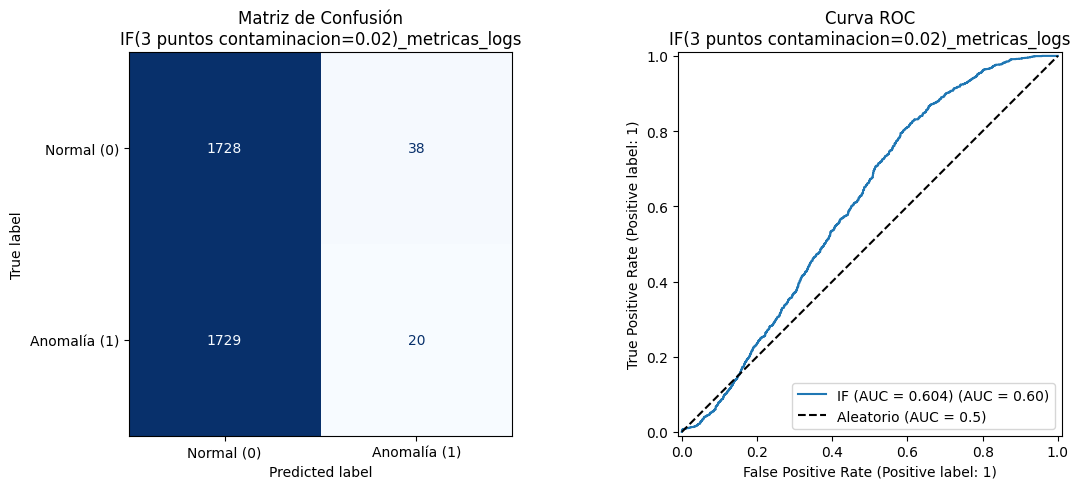

Accuracy    = 0.5001422475106686
Precision   = 0.4090909090909091
Recall      = 0.010291595197255575
Specificity = 0.9852774631936579
F1          = 0.020078081427774678


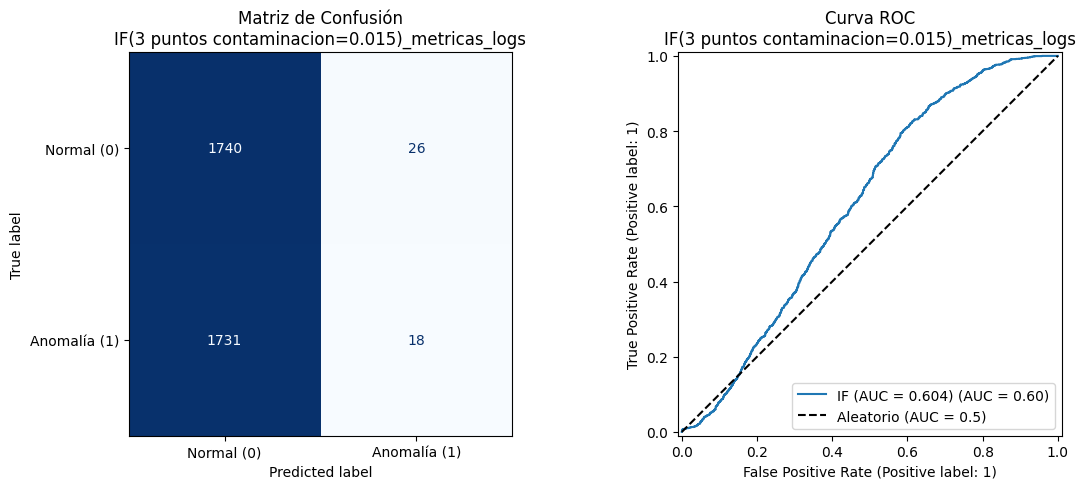

Accuracy    = 0.5018492176386913
Precision   = 0.47058823529411764
Recall      = 0.009148084619782733
Specificity = 0.9898074745186863
F1          = 0.0179472798653954


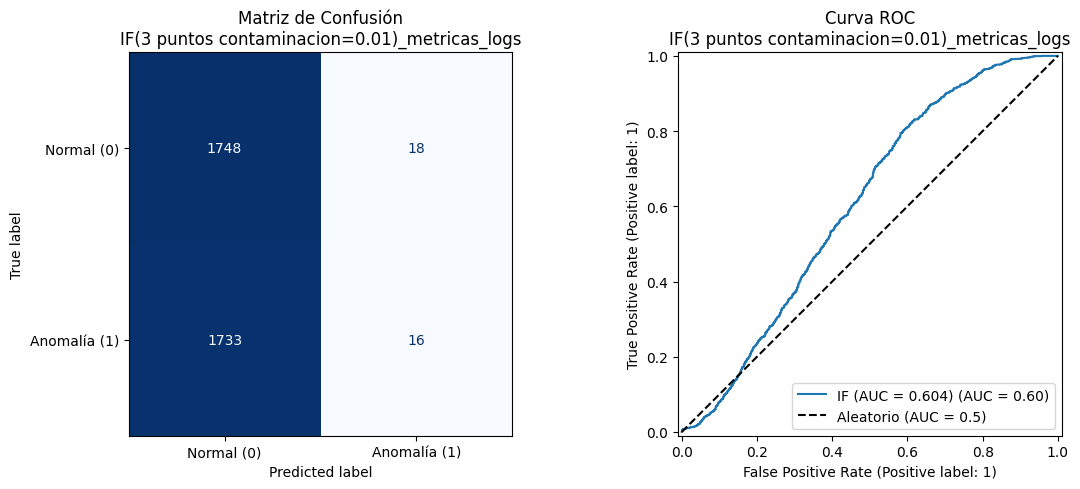

Accuracy    = 0.5021337126600285
Precision   = 0.4827586206896552
Recall      = 0.008004574042309892
Specificity = 0.9915062287655719
F1          = 0.015748031496062992


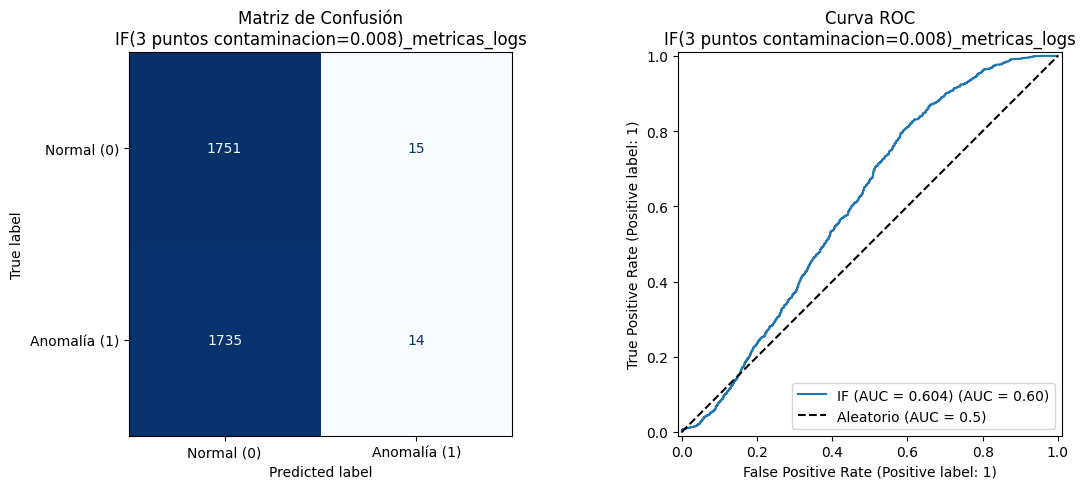

Accuracy    = 0.5035561877667141
Precision   = 0.5909090909090909
Recall      = 0.007432818753573471
Specificity = 0.9949037372593431
F1          = 0.014680971202710334


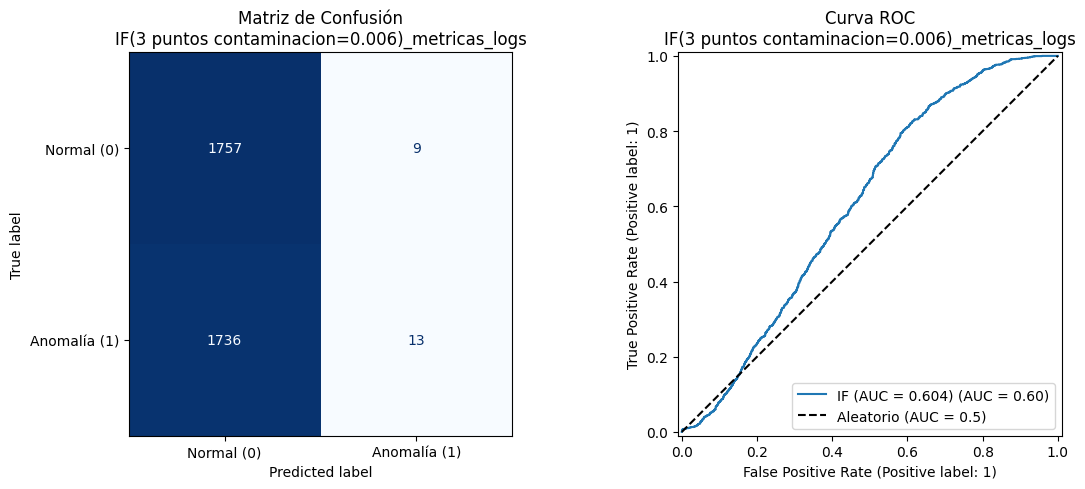

Accuracy    = 0.5041251778093884
Precision   = 0.6875
Recall      = 0.006289308176100629
Specificity = 0.9971687429218573
F1          = 0.012464589235127478


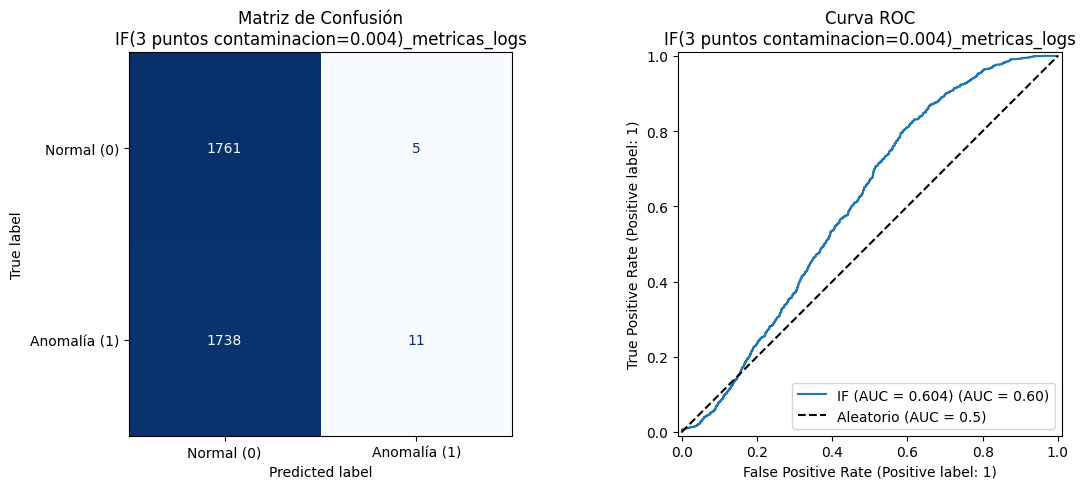

Accuracy    = 0.5046941678520626
Precision   = 0.7857142857142857
Recall      = 0.006289308176100629
Specificity = 0.9983012457531144
F1          = 0.012478729438457176


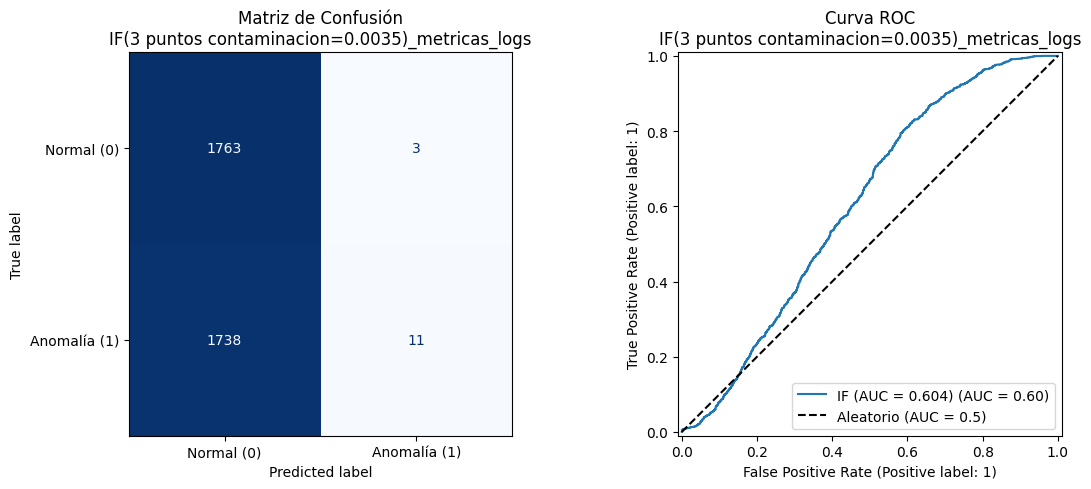

Accuracy    = 0.5049786628733998
Precision   = 0.8461538461538461
Recall      = 0.006289308176100629
Specificity = 0.9988674971687429
F1          = 0.012485811577752554


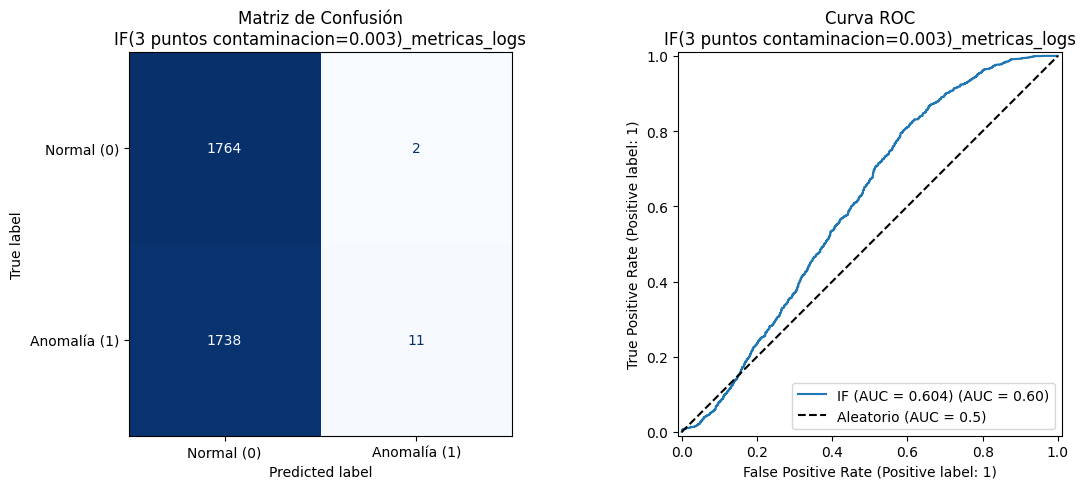

Accuracy    = 0.5044096728307255
Precision   = 0.8181818181818182
Recall      = 0.005145797598627788
Specificity = 0.9988674971687429
F1          = 0.010227272727272727


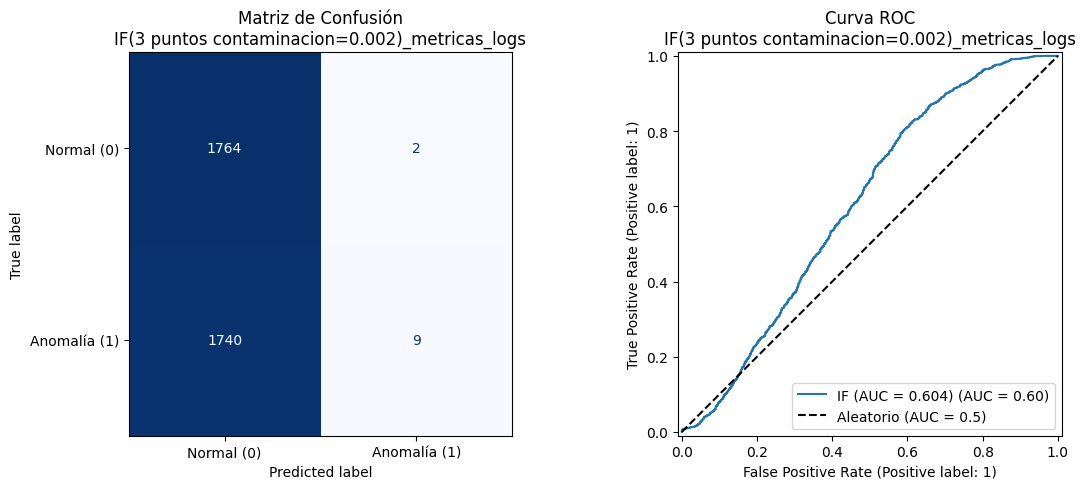

Accuracy    = 0.5029871977240399
Precision   = 0.75
Recall      = 0.0017152658662092624
Specificity = 0.9994337485843715
F1          = 0.0034227039361095267


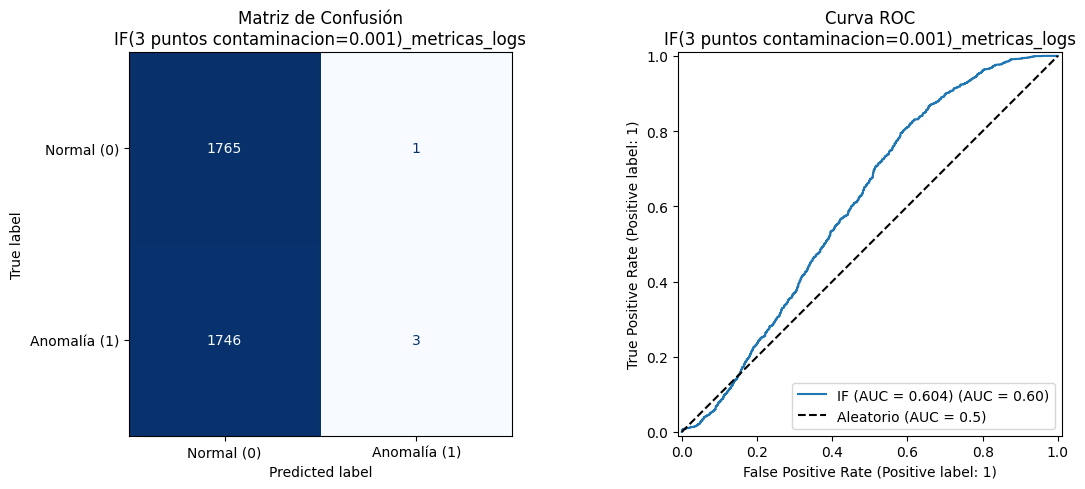

Accuracy    = 0.5021337126600285
Precision   = 0.0
Recall      = 0.0
Specificity = 0.9994337485843715
F1          = 0.0


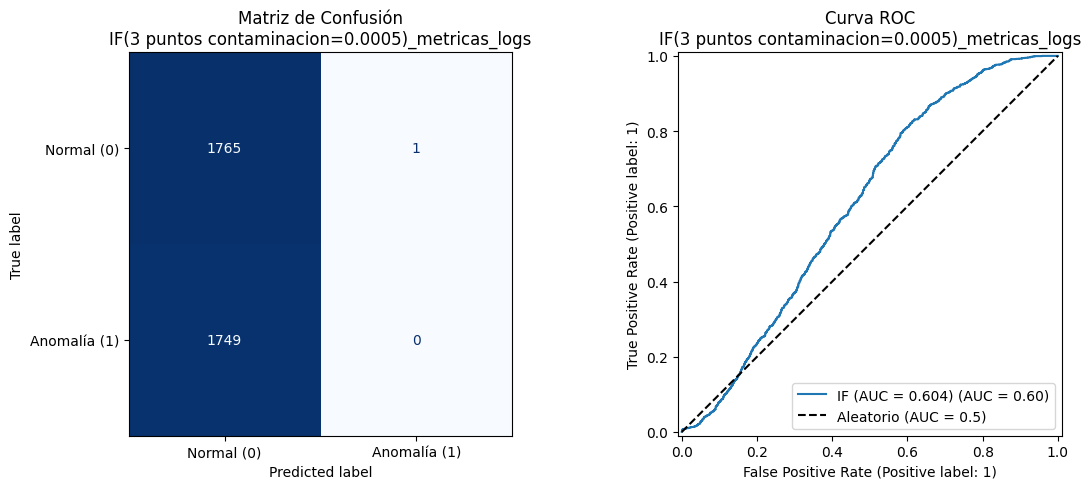

In [26]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_test, 'execution_name'],
    'label': df.loc[idx_test, 'label']
})

N = 0
lista_result=[]
for contaminacion in [0.02, 0.015, 0.01, 0.008, 0.006, 0.004, 0.0035, 0.003, 0.002, 0.001, 0.0005]:
    N += 1
    model = IsolationForest(
        n_estimators=200, 
        max_samples='auto', 
        contamination=contaminacion,        
        #contamination='auto', 
        random_state=SEED
    )
    model.fit(X_correct_train)
    scores = model.decision_function(X_test)
    Y_pred = model.predict(X_test)

    model_name = f'IF(3 puntos contaminacion={contaminacion})_metricas_logs'
    joblib.dump(model, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    
    df_result[f'result_({model_name})'] = float('nan')
    df_result[f'scores_({model_name})'] = float('nan')
    df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
    df_result.loc[idx_test, f'scores_({model_name})'] = scores
    
    # Mapeo: 1 para Anomalía (Positivo) y 0 para Normal (Negativo)
    y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    #y_pred = df_result.loc[idx_test, f'result_({model_name})'].apply(lambda x: 0 if x == 1 else 1)
    y_pred = df_result.loc[idx_test, f'result_({model_name})'].map({1: 0, -1: 1})

    
    # Invertimos los scores para que valores más altos correspondan a la anomalía
    y_scores_roc = -scores 
    roc_auc = roc_auc_score(y_true, y_scores_roc)

    # 1. Componentes de la matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # 2. Cálculo de métricas
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f'Accuracy    = {acc}')
    print(f'Precision   = {precision}')
    print(f'Recall      = {recall}')
    print(f'Specificity = {specificity}')
    print(f'F1          = {f1}')
    
    parametros = {'contaminacion': contaminacion}
    
    # 3. Guardar en un diccionario de registro
    reg_resultado_algoritmo = {
        'test_name': model_name,
        'parametros': json.dumps(parametros),
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1),
        'roc_auc': float(roc_auc)
    }
    lista_result.append(reg_resultado_algoritmo)
    
    # 4. Visualización conjunta (Matriz de Confusión a la izquierda, Curva ROC a la derecha)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gráfica izquierda: Matriz de Confusión
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
    disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Matriz de Confusión\n{model_name}')
    
    # Gráfica derecha: Curva ROC
    RocCurveDisplay.from_predictions(
        y_true, 
        y_scores_roc, 
        ax=axes[1], 
        name=f'IF (AUC = {roc_auc:.3f})'
    )
    axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
    axes[1].set_title(f'Curva ROC\n{model_name}')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

    paquete = {
        'model_name' : model_name,
        'model'      : model,
        'parametros' : {'contaminacion':contaminacion},
        'resultado'  : {'accuracy':acc,'precision':precision,'recall':recall,'f1':f1,'specificity':specificity}
    }
    joblib.dump(paquete, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    
# DataFrame global final
df_anomaly_detection_summary = pd.DataFrame(lista_result)

### <span style="color:#2ca02c">2.2. Probamos IF(3 puntos) ajustando umbral de decision con indice de Youden</span>

In [27]:
df_result=df.copy()

In [28]:
with open(filename_lista_metric_name_vector, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

In [29]:
X_matrix.shape

(44126, 993)

In [30]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()

In [31]:


# 4. Recortamos los datos de entrenamiento y test con este nuevo subconjunto
X_correct_train = X_matrix[idx_correct_train]
X_correct_test  = X_matrix[idx_correct_test]
X_test          = X_matrix[idx_test]
X_val           = X_matrix[idx_val]



--- IF(3 puntos umbral indice Youden)_metricas_logs (Umbral Youden: -0.0936) ---
Accuracy    = 0.6022759601706971
Precision   = 0.565168956554029
Recall      = 0.8702115494568324
Specificity = 0.3369195922989808
F1          = 0.6852769022962629


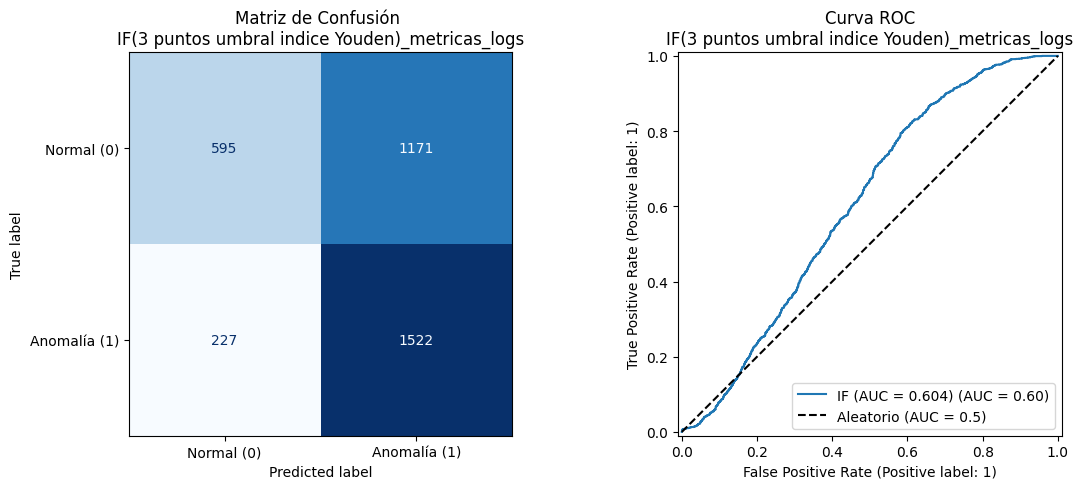

['result/models/IF(3 puntos umbral indice Youden)_metricas_logs.joblib']

In [33]:

model_name = f'IF(3 puntos umbral indice Youden)_metricas_logs'
N += 1

# 2. Entrenar el Isolation Forest
model = IsolationForest(
    n_estimators=200, 
    max_samples='auto', 
    contamination=0.001,      
    random_state=SEED
)
model.fit(X_correct_train)


#usamos el conjunto de validacion para obtener curva ROC y establecer el umbral de decision usnado indice de Youden
#y_true = df_result.iloc[idx_val]['label'].apply(lambda x: 0 if x == 'correct' else 1)
y_true = df_result.loc[idx_val, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
scores = model.decision_function(X_val)
y_scores_roc = -scores  
roc_auc = roc_auc_score(y_true, y_scores_roc)
fpr, tpr, thresholds = roc_curve(y_true, y_scores_roc)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

#calcumamos la prediccion para el conjunto de test
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
scores = model.decision_function(X_test)
y_scores_roc = -scores  
roc_auc = roc_auc_score(y_true, y_scores_roc)
fpr, tpr, thresholds = roc_curve(y_true, y_scores_roc)
y_pred = (y_scores_roc >= optimal_threshold).astype(int)



# Guardar en el DataFrame global
df_result[f'result_({model_name})'] = float('nan')
df_result[f'scores_({model_name})'] = float('nan')
df_result.loc[idx_test, f'result_({model_name})'] = y_pred
df_result.loc[idx_test, f'scores_({model_name})'] = scores

# 6. Métricas y matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f'--- {model_name} (Umbral Youden: {optimal_threshold:.4f}) ---')
print(f'Accuracy    = {acc}')
print(f'Precision   = {precision}')
print(f'Recall      = {recall}')
print(f'Specificity = {specificity}')    
print(f'F1          = {f1}')

parametros = {'contaminacion': contaminacion, 'metodo': 'youden', 'umbral_youden': float(optimal_threshold)}

reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc)
}
lista_result.append(reg_resultado_algoritmo)

# 7. Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusión \n{model_name}')

RocCurveDisplay.from_predictions(y_true, y_scores_roc, ax=axes[1], name=f'IF (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
axes[1].set_title(f'Curva ROC\n{model_name}')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

paquete = {
    'model_name' : model_name,
    'model'      : model,
    'parametros' : {'contaminacion':contaminacion,'threshold':optimal_threshold},
    'resultado'  : {'accuracy':acc,'precision':precision,'recall':recall,'f1':f1,'specificity':specificity}
}
joblib.dump(paquete, f'{FOLDER_SALIDA}/models/{model_name}.joblib')



    

## <span style="color:#2ca02c">2.3.Probamos IF(1 puntos seleccionado cada punto) con varios parametros contaminacion</span>

In [66]:
with open(filename_lista_metric_name_vector, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

In [67]:
X_matrix.shape

(44126, 993)

In [68]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()

In [69]:
# 1. Elige el tercio que quieres extraer (1, 2 o 3)
tercio_deseado = 2  # Cambia esto a 1, 2 o según convenga

# 2. Calculamos los tamaños y los índices de inicio y fin
num_columnas_total = X_matrix.shape[1]
tercio_n = num_columnas_total // 3  # División entera

inicio_idx = (tercio_deseado - 1) * tercio_n

# Para el último tercio (tercio 3), nos aseguramos de coger hasta el final por si hay decimales sobrantes en la división entera
if tercio_deseado == 3:
    fin_idx = num_columnas_total
else:
    fin_idx = tercio_deseado * tercio_n

print(f"Total de columnas: {num_columnas_total}")
print(f"Extrayendo el tercio {tercio_deseado} (desde la columna {inicio_idx} hasta la {fin_idx})")

# 3. Seleccionamos el tercio correspondiente de las columnas en la matriz global
X_matrix_reducida = X_matrix[:, inicio_idx:fin_idx]

# 4. Recortamos los datos de entrenamiento y test con este nuevo subconjunto
X_correct_train = X_matrix_reducida[idx_correct_train]
X_correct_test  = X_matrix_reducida[idx_correct_test]
X_test          = X_matrix_reducida[idx_test]
X_val           = X_matrix_reducida[idx_val]

# 5. Ajustamos también el vector de nombres de las características para que coincida exactamente
lista_metric_name_vector = lista_metric_name_vector[inicio_idx:fin_idx]

Total de columnas: 993
Extrayendo el tercio 2 (desde la columna 331 hasta la 662)


In [70]:
X_matrix_reducida.shape

(44126, 331)

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


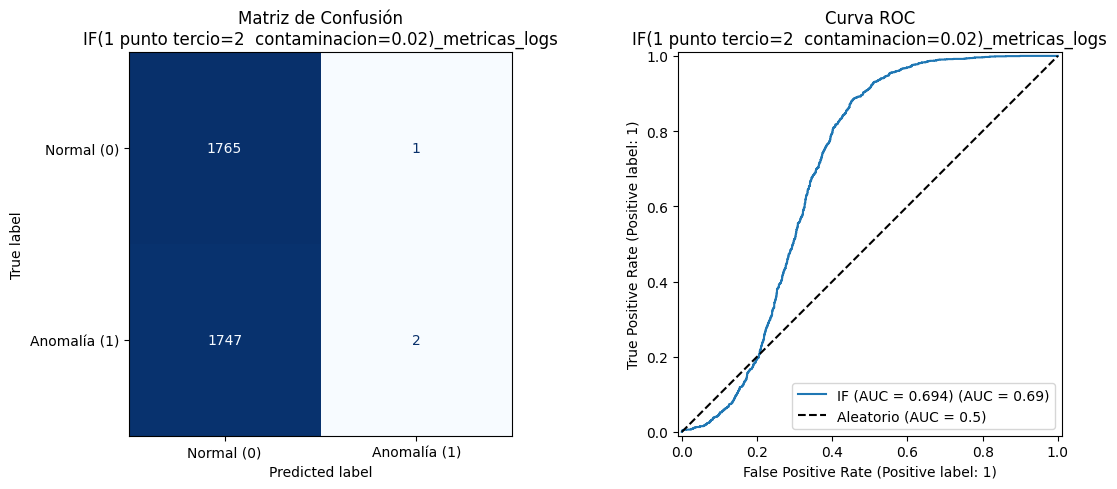

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


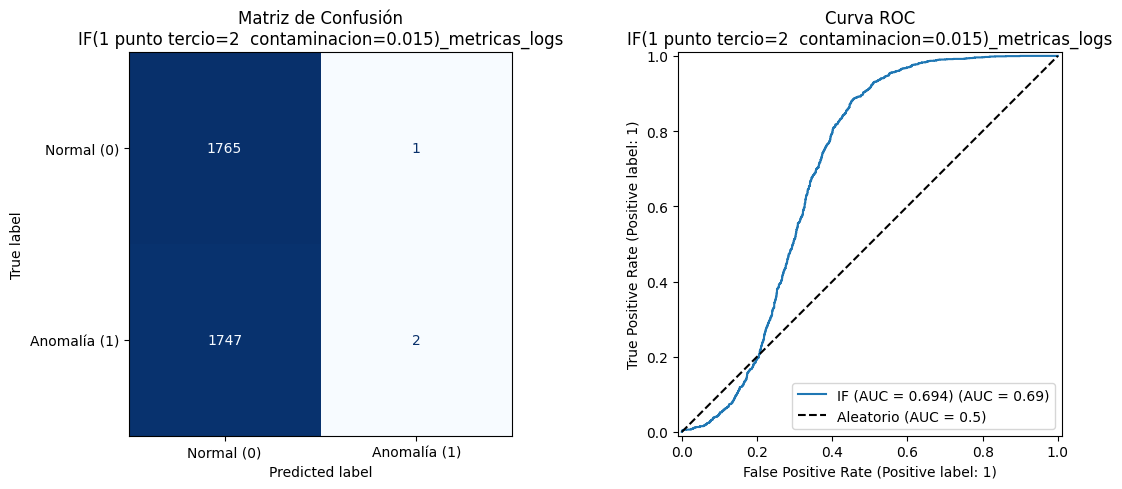

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


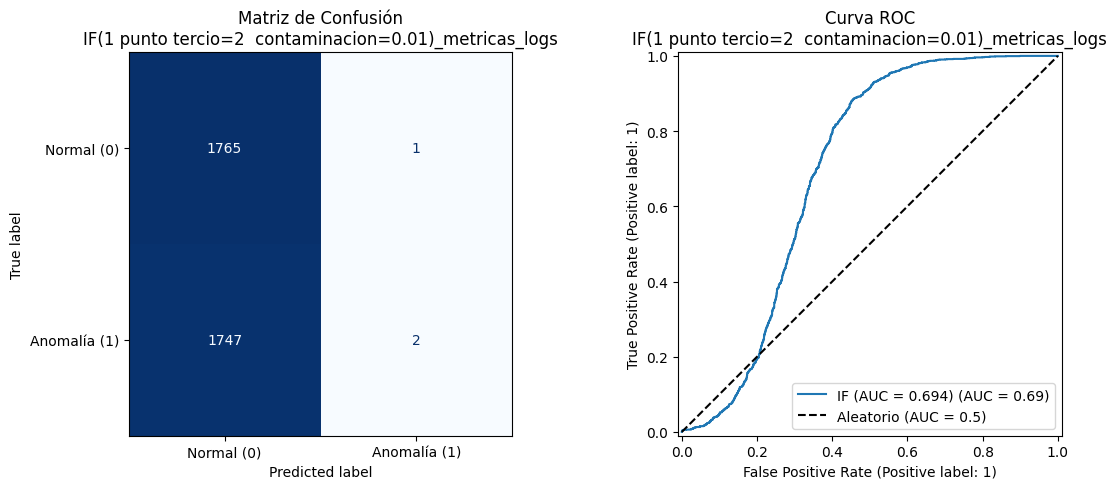

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


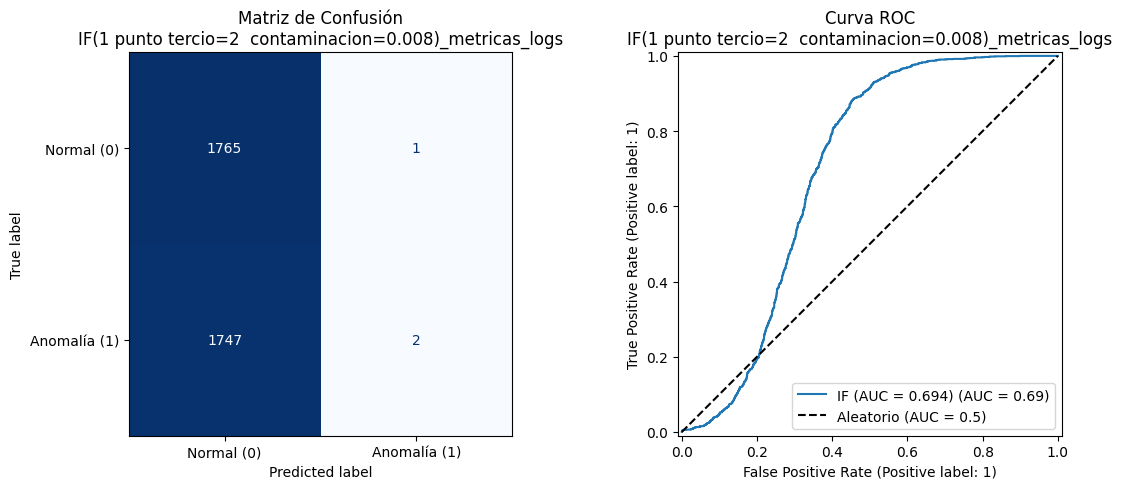

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


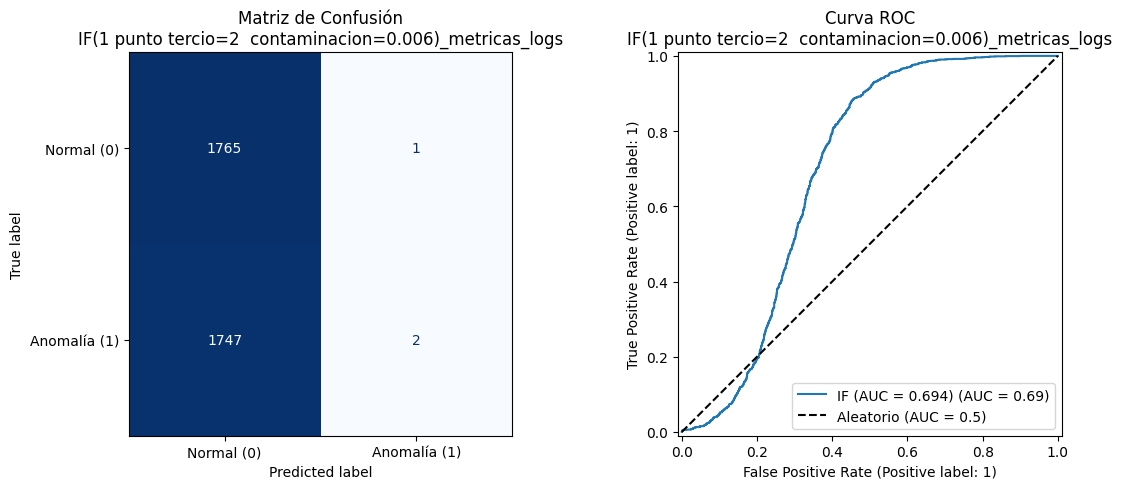

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


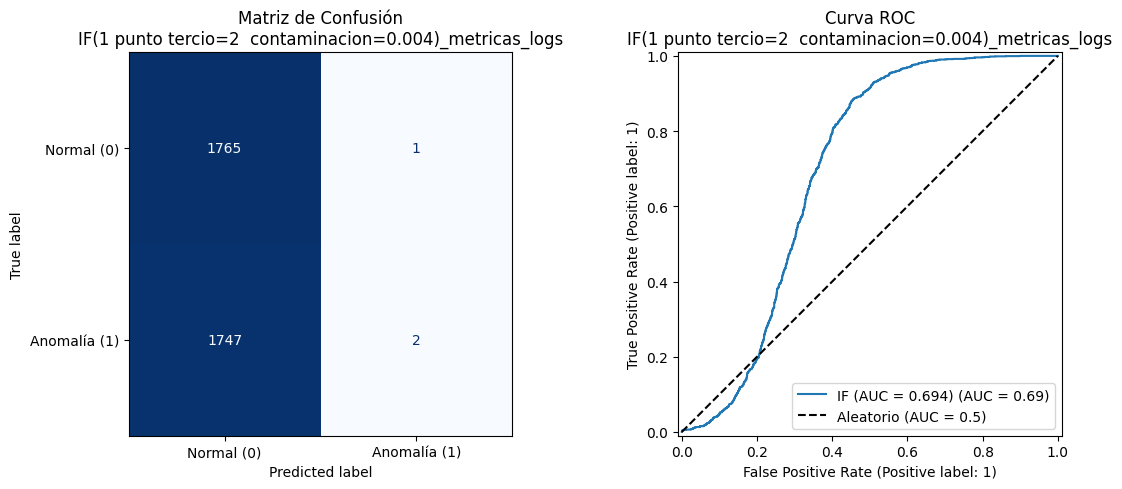

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


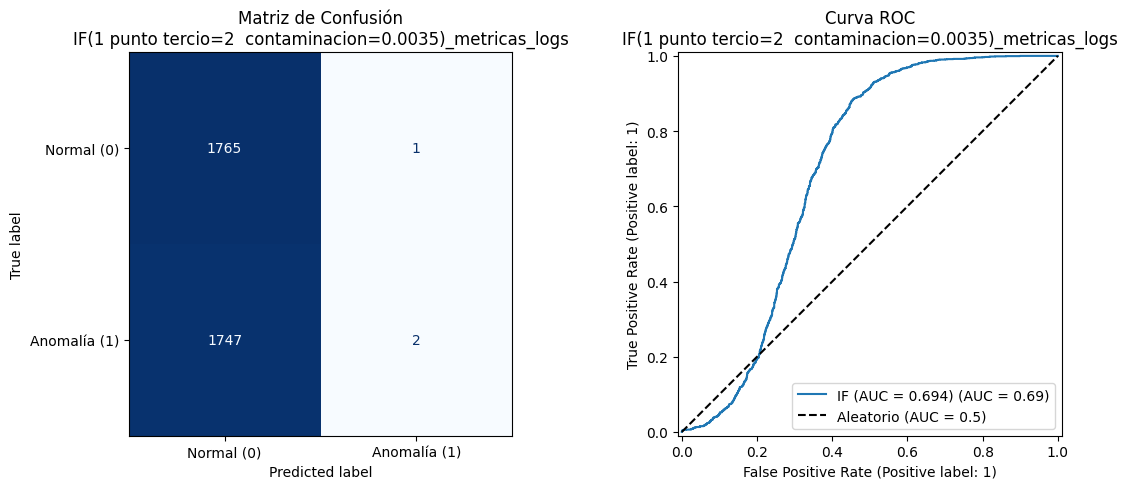

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


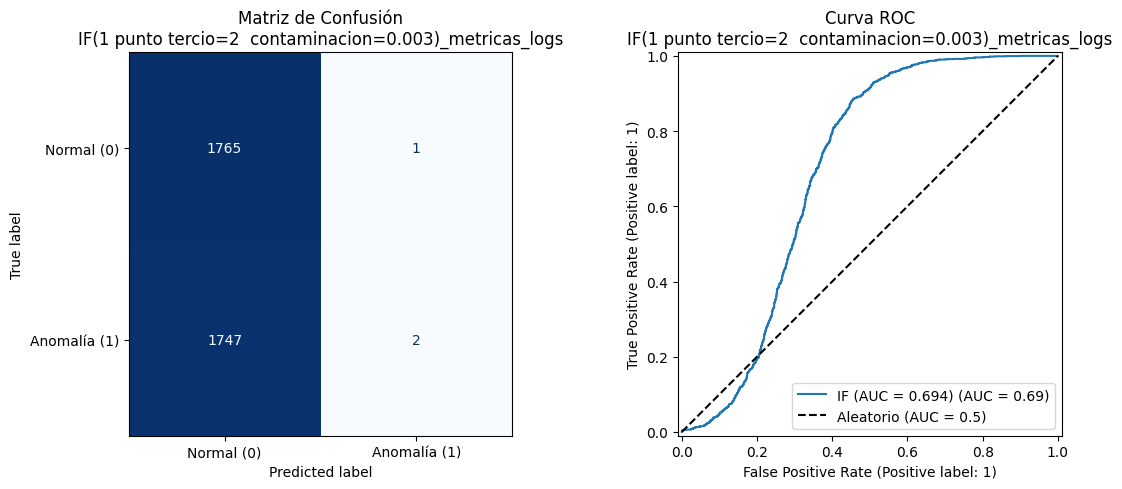

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


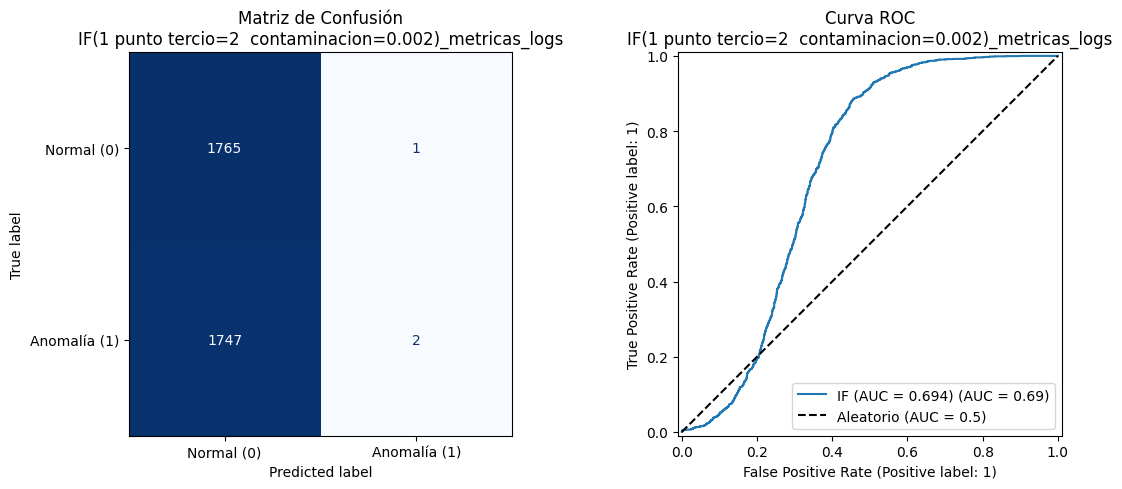

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


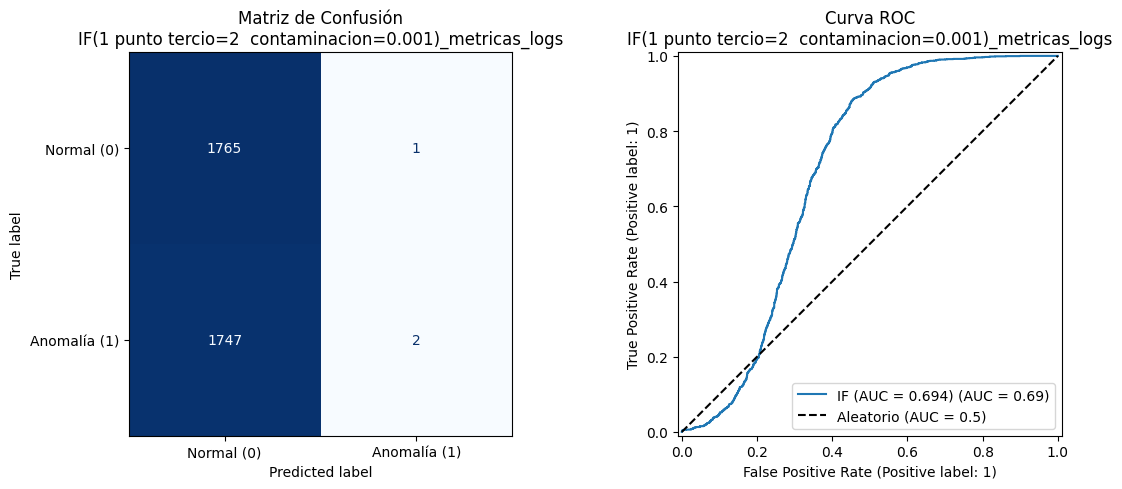

Accuracy    = 0.5027027027027027
Precision   = 0.6666666666666666
Recall      = 0.0011435105774728416
Specificity = 0.9994337485843715
F1          = 0.00228310502283105


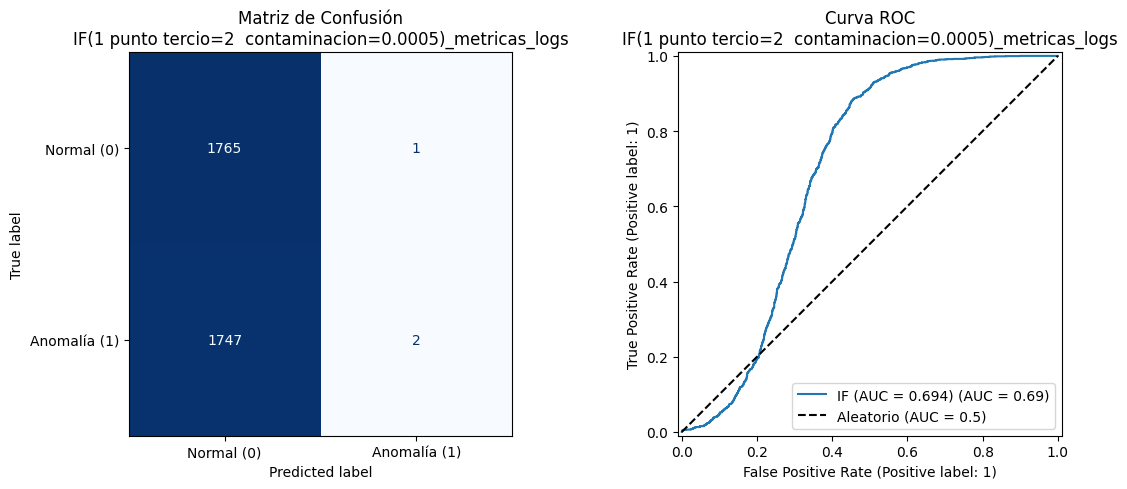

In [71]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_test, 'execution_name'],
    'label': df.loc[idx_test, 'label']
})

N = 0
lista_result=[]
for contaminacion in [0.02, 0.015, 0.01, 0.008, 0.006, 0.004, 0.0035, 0.003, 0.002, 0.001, 0.0005]:
    N += 1
    model = IsolationForest(
        n_estimators=200, 
        max_samples='auto', 
        #contamination=contaminacion,        
        contamination='auto', 
        random_state=SEED
    )
    model.fit(X_correct_train)
    scores = model.decision_function(X_test)
    Y_pred = model.predict(X_test)

    model_name = f'IF(1 punto tercio={tercio_deseado}  contaminacion={contaminacion})_metricas_logs'
    joblib.dump(model, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    
    df_result[f'result_({model_name})'] = float('nan')
    df_result[f'scores_({model_name})'] = float('nan')
    df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
    df_result.loc[idx_test, f'scores_({model_name})'] = scores
    
    # Mapeo: 1 para Anomalía (Positivo) y 0 para Normal (Negativo)
    y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    #y_pred = df_result.loc[idx_test, f'result_({model_name})'].apply(lambda x: 0 if x == 1 else 1)
    y_pred = df_result.loc[idx_test, f'result_({model_name})'].map({1: 0, -1: 1})

    
    # Invertimos los scores para que valores más altos correspondan a la anomalía
    y_scores_roc = -scores 
    roc_auc = roc_auc_score(y_true, y_scores_roc)

    # 1. Componentes de la matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # 2. Cálculo de métricas
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f'Accuracy    = {acc}')
    print(f'Precision   = {precision}')
    print(f'Recall      = {recall}')
    print(f'Specificity = {specificity}')
    print(f'F1          = {f1}')
    
    parametros = {'contaminacion': contaminacion}
    
    # 3. Guardar en un diccionario de registro
    reg_resultado_algoritmo = {
        'test_name': model_name,
        'parametros': json.dumps(parametros),
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1),
        'roc_auc': float(roc_auc)
    }
    lista_result.append(reg_resultado_algoritmo)
    
    # 4. Visualización conjunta (Matriz de Confusión a la izquierda, Curva ROC a la derecha)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gráfica izquierda: Matriz de Confusión
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
    disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Matriz de Confusión\n{model_name}')
    
    # Gráfica derecha: Curva ROC
    RocCurveDisplay.from_predictions(
        y_true, 
        y_scores_roc, 
        ax=axes[1], 
        name=f'IF (AUC = {roc_auc:.3f})'
    )
    axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
    axes[1].set_title(f'Curva ROC\n{model_name}')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

    paquete = {
        'model_name' : model_name,
        'model'      : model,
        'parametros' : {'contaminacion':contaminacion},
        'resultado'  : {'accuracy':acc,'precision':precision,'recall':recall,'f1':f1,'specificity':specificity}
    }
    joblib.dump(paquete, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    
# DataFrame global final
df_anomaly_detection_summary = pd.DataFrame(lista_result)

### <span style="color:#2ca02c">2.4. Probamos IF(1 puntos seleccionado cada punto) ajustando umbral de decision con indice de Youden</span>

In [134]:
with open(filename_lista_metric_name_vector, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

In [135]:
X_matrix.shape

(44126, 993)

In [136]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()

In [137]:
# 1. Elige el tercio que quieres extraer (1, 2 o 3)
tercio_deseado = 2  # Cambia esto a 1, 2 o según convenga

# 2. Calculamos los tamaños y los índices de inicio y fin
num_columnas_total = X_matrix.shape[1]
tercio_n = num_columnas_total // 3  # División entera

inicio_idx = (tercio_deseado - 1) * tercio_n

# Para el último tercio (tercio 3), nos aseguramos de coger hasta el final por si hay decimales sobrantes en la división entera
if tercio_deseado == 3:
    fin_idx = num_columnas_total
else:
    fin_idx = tercio_deseado * tercio_n

print(f"Total de columnas: {num_columnas_total}")
print(f"Extrayendo el tercio {tercio_deseado} (desde la columna {inicio_idx} hasta la {fin_idx})")

# 3. Seleccionamos el tercio correspondiente de las columnas en la matriz global
X_matrix_reducida = X_matrix[:, inicio_idx:fin_idx]

# 4. Recortamos los datos de entrenamiento y test con este nuevo subconjunto
X_correct_train = X_matrix_reducida[idx_correct_train]
X_correct_test  = X_matrix_reducida[idx_correct_test]
X_test          = X_matrix_reducida[idx_test]
X_val           = X_matrix_reducida[idx_val]

# 5. Ajustamos también el vector de nombres de las características para que coincida exactamente
lista_metric_name_vector = lista_metric_name_vector[inicio_idx:fin_idx]

Total de columnas: 993
Extrayendo el tercio 2 (desde la columna 331 hasta la 662)


In [140]:
X_matrix_reducida.shape

(44126, 331)

--- IF(1 punto umbral tercio =2     indice Youden)_metricas_logs (Umbral Youden: -0.1117) ---
Accuracy    = 0.7081081081081081
Precision   = 0.6580673371228684
Recall      = 0.8604917095483133
Specificity = 0.5571913929784824
F1          = 0.7457879088206145


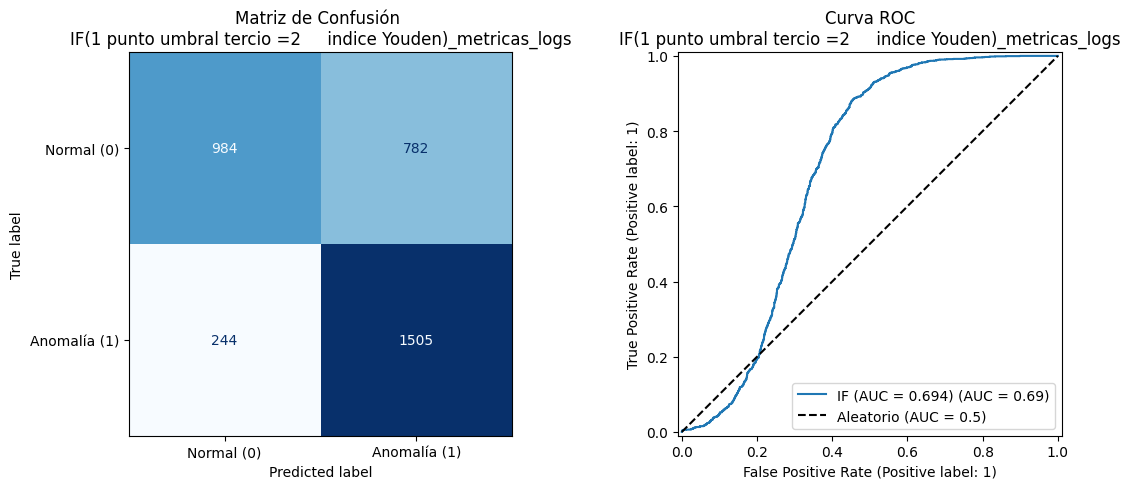

['result/models/IF(1 punto umbral tercio =2     indice Youden)_metricas_logs.joblib']

In [139]:

model_name = f'IF(1 punto umbral tercio ={tercio_deseado}     indice Youden)_metricas_logs'
N += 1

# 2. Entrenar el Isolation Forest
model = IsolationForest(
    n_estimators=200, 
    max_samples='auto', 
    contamination='auto',        
    random_state=SEED
)
model.fit(X_correct_train)


#usamos el conjunto de validacion para obtener curva ROC y establecer el umbral de decision usnado indice de Youden
#y_true = df_result.iloc[idx_val]['label'].apply(lambda x: 0 if x == 'correct' else 1)
y_true = df_result.loc[idx_val, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
scores = model.decision_function(X_val)
y_scores_roc = -scores  
roc_auc = roc_auc_score(y_true, y_scores_roc)
fpr, tpr, thresholds = roc_curve(y_true, y_scores_roc)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

#calcumamos la prediccion para el conjunto de test
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
scores = model.decision_function(X_test)
y_scores_roc = -scores  
roc_auc = roc_auc_score(y_true, y_scores_roc)
fpr, tpr, thresholds = roc_curve(y_true, y_scores_roc)
y_pred = (y_scores_roc >= optimal_threshold).astype(int)



# Guardar en el DataFrame global
df_result[f'result_({model_name})'] = float('nan')
df_result[f'scores_({model_name})'] = float('nan')
df_result.loc[idx_test, f'result_({model_name})'] = y_pred
df_result.loc[idx_test, f'scores_({model_name})'] = scores

# 6. Métricas y matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f'--- {model_name} (Umbral Youden: {optimal_threshold:.4f}) ---')
print(f'Accuracy    = {acc}')
print(f'Precision   = {precision}')
print(f'Recall      = {recall}')
print(f'Specificity = {specificity}')    
print(f'F1          = {f1}')

parametros = {'contaminacion': contaminacion, 'metodo': 'youden', 'umbral_youden': float(optimal_threshold)}

reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc)
}
lista_result.append(reg_resultado_algoritmo)

# 7. Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusión \n{model_name}')

RocCurveDisplay.from_predictions(y_true, y_scores_roc, ax=axes[1], name=f'IF (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
axes[1].set_title(f'Curva ROC\n{model_name}')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

paquete = {
    'model_name' : model_name,
    'model'      : model,
    'parametros' : {'contaminacion':contaminacion,'threshold':optimal_threshold},
    'resultado'  : {'accuracy':acc,'precision':precision,'recall':recall,'f1':f1,'specificity':specificity}
}
joblib.dump(paquete, f'{FOLDER_SALIDA}/models/{model_name}.joblib')



    

## <span style="color:#2ca02c">2.5.Probamos IF(1 puntos de 3 intervalos) con varios parametros contaminacion</span>

In [66]:
with open(filename_lista_metric_name_vector, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

In [67]:
X_matrix.shape

(44126, 993)

In [68]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()

In [77]:

# 1. Calculamos los tamaños de los tercios
num_columnas_total = X_matrix.shape[1]
tercio_n = num_columnas_total // 3

# Definimos los límites de los 3 tercios
inicio_1, fin_1 = 0, tercio_n
inicio_2, fin_2 = tercio_n, tercio_n * 2
inicio_3, fin_3 = tercio_n * 2, num_columnas_total  # Coge el resto hasta el final por si acaso

# 2. Extraemos cada tercio como una submatriz
t1 = X_matrix[:, inicio_1:fin_1]
t2 = X_matrix[:, inicio_2:fin_2]
t3 = X_matrix[:, inicio_3:fin_3]

# 3. Sumamos las columnas homólogas de los tres tercios (columna i del tercio 1 + columna i del tercio 2 + columna i del tercio 3)
# Como t1, t2 y t3 tienen exactamente la misma forma (n_filas, tercio_n), la suma de NumPy los alinea automáticamente.
X_matrix_reducida = t1 + t2 + t3

print(f"Total de columnas originales: {num_columnas_total}")
print(f"Columnas por tercio: {tercio_n}")
print(f"Nueva forma de X_matrix_reducida: {X_matrix_reducida.shape}")

# 4. Recortamos los datos de entrenamiento y test con esta nueva matriz reducida
X_correct_train = X_matrix_reducida[idx_correct_train]
X_correct_test  = X_matrix_reducida[idx_correct_test]
X_test          = X_matrix_reducida[idx_test]
X_val           = X_matrix_reducida[idx_val]

# 5. Ajustamos la lista de nombres de métricas cogiendo el patrón del primer tercio (o renombrándolas)
# Esto asume que el nombre de la característica i en el tercio 1 corresponde al mismo concepto que en los otros tercios
lista_metric_name_vector = lista_metric_name_vector[inicio_1:fin_1]

Total de columnas originales: 993
Columnas por tercio: 331
Nueva forma de X_matrix_reducida: (44126, 331)


In [78]:
X_matrix_reducida.shape

(44126, 331)

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


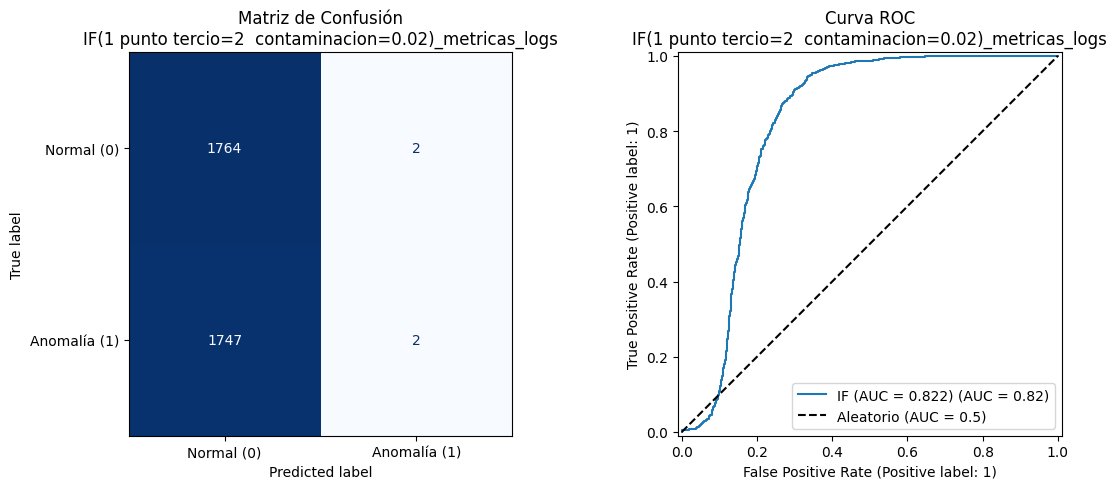

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


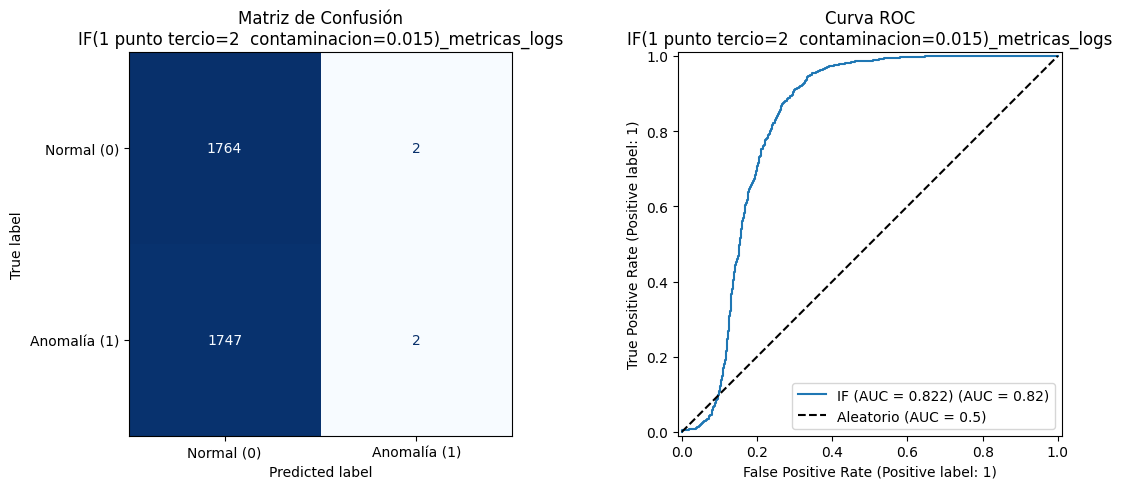

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


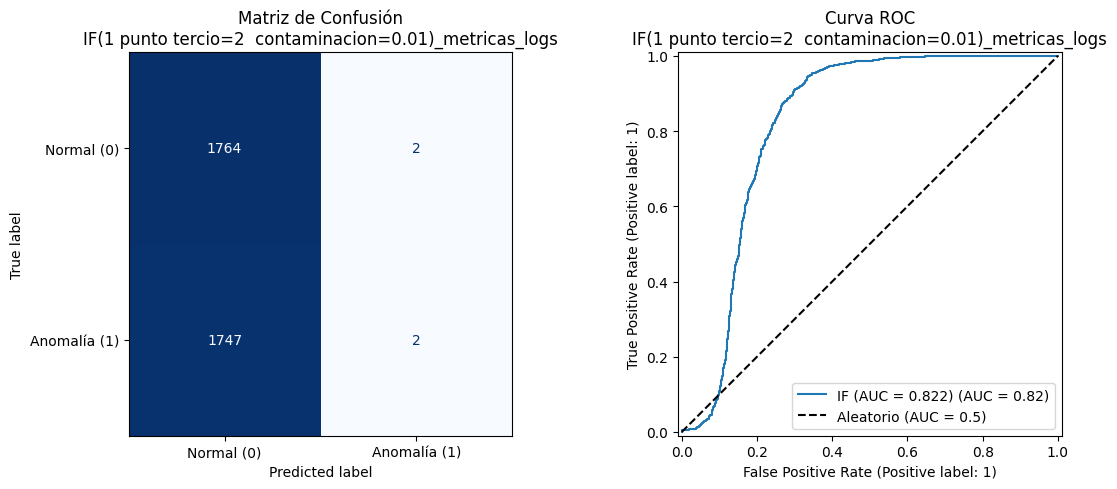

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


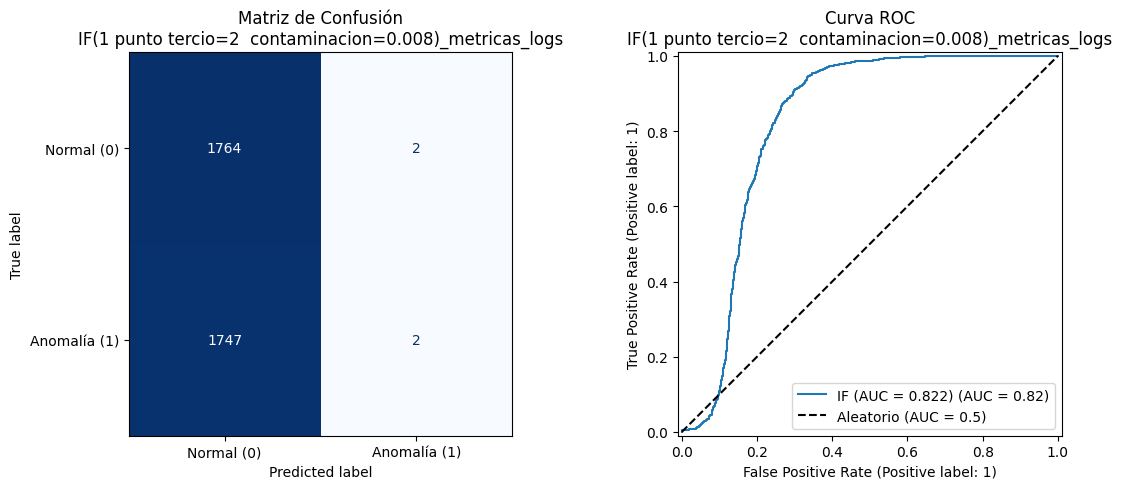

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


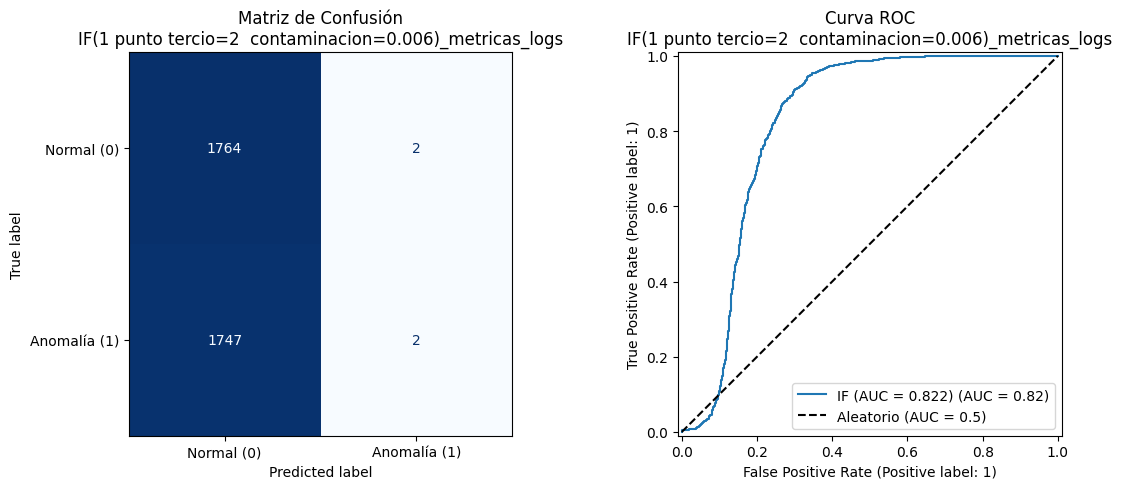

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


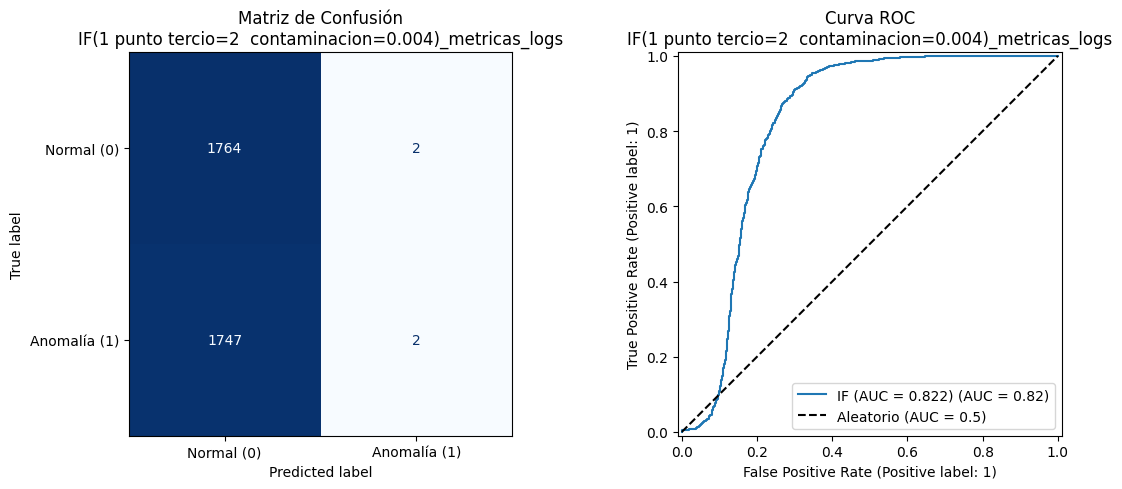

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


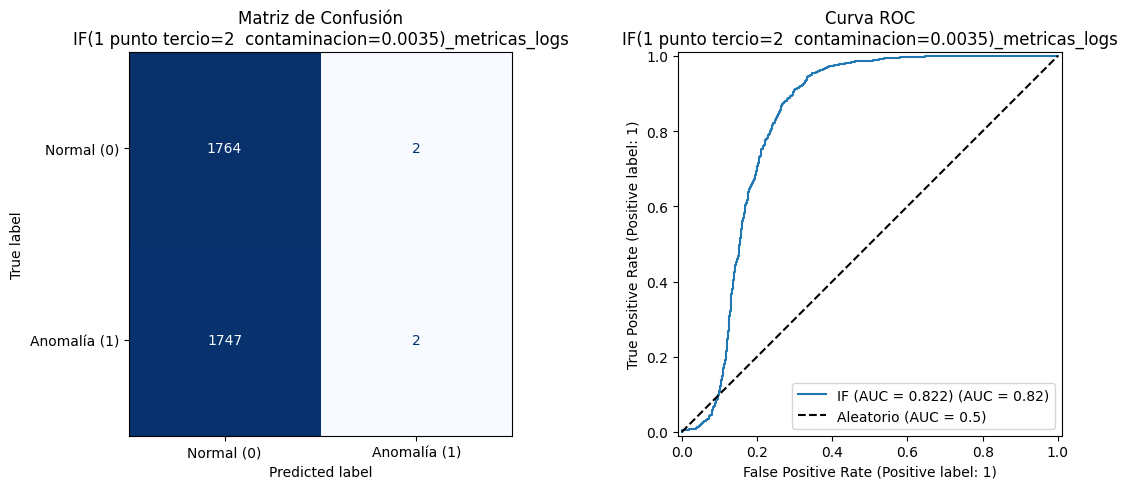

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


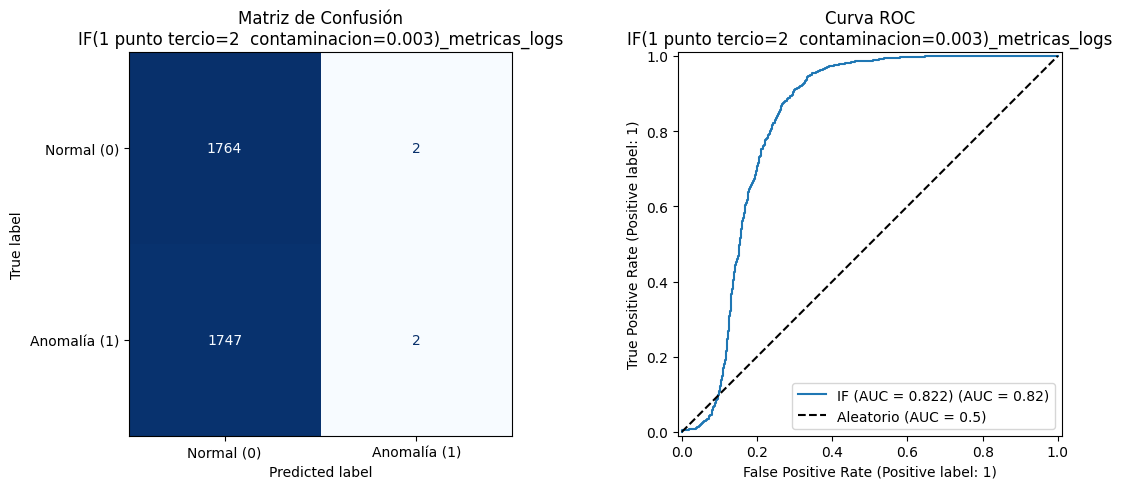

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


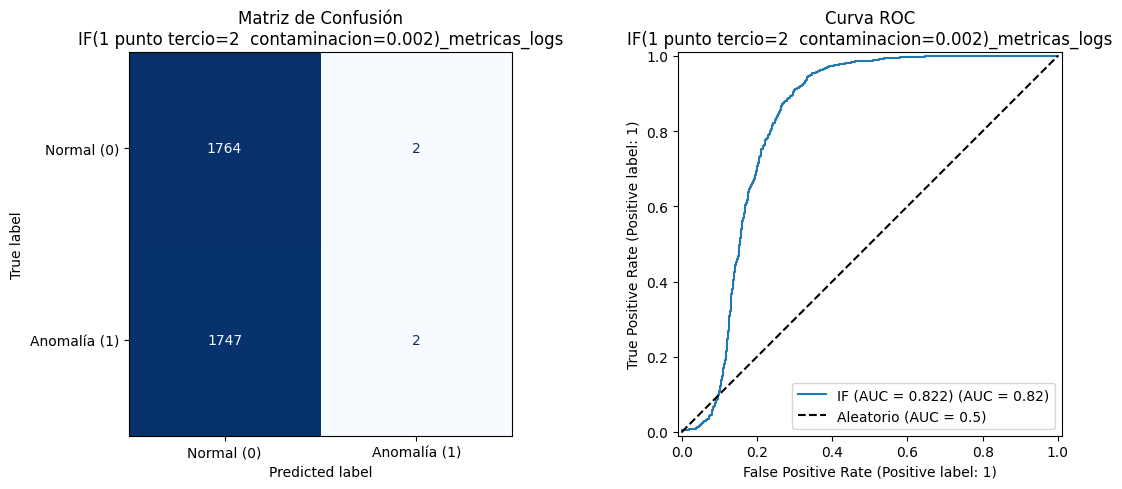

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


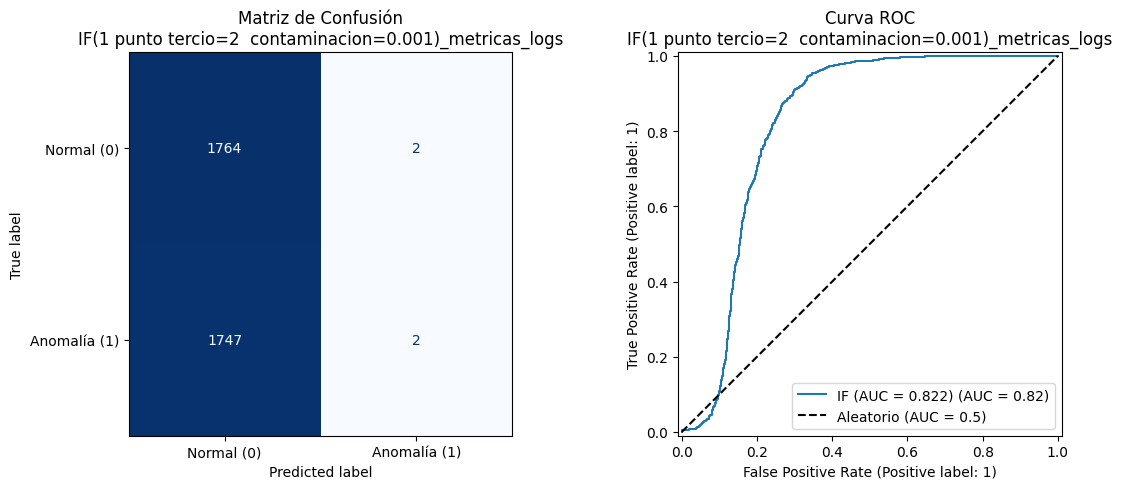

Accuracy    = 0.5024182076813656
Precision   = 0.5
Recall      = 0.0011435105774728416
Specificity = 0.9988674971687429
F1          = 0.0022818026240730175


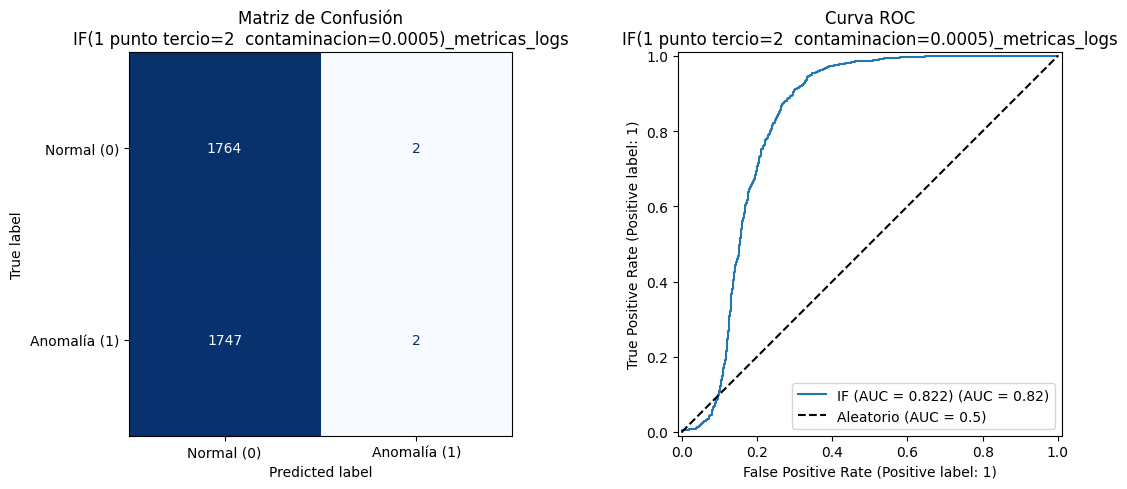

In [79]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_test, 'execution_name'],
    'label': df.loc[idx_test, 'label']
})

N = 0
lista_result=[]
for contaminacion in [0.02, 0.015, 0.01, 0.008, 0.006, 0.004, 0.0035, 0.003, 0.002, 0.001, 0.0005]:
    N += 1
    model = IsolationForest(
        n_estimators=200, 
        max_samples='auto', 
        #contamination=contaminacion,        
        contamination='auto', 
        random_state=SEED
    )
    model.fit(X_correct_train)
    scores = model.decision_function(X_test)
    Y_pred = model.predict(X_test)

    model_name = f'IF(1 punto tercio={tercio_deseado}  contaminacion={contaminacion})_metricas_logs'
    joblib.dump(model, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    
    df_result[f'result_({model_name})'] = float('nan')
    df_result[f'scores_({model_name})'] = float('nan')
    df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
    df_result.loc[idx_test, f'scores_({model_name})'] = scores
    
    # Mapeo: 1 para Anomalía (Positivo) y 0 para Normal (Negativo)
    y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    #y_pred = df_result.loc[idx_test, f'result_({model_name})'].apply(lambda x: 0 if x == 1 else 1)
    y_pred = df_result.loc[idx_test, f'result_({model_name})'].map({1: 0, -1: 1})

    
    # Invertimos los scores para que valores más altos correspondan a la anomalía
    y_scores_roc = -scores 
    roc_auc = roc_auc_score(y_true, y_scores_roc)

    # 1. Componentes de la matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # 2. Cálculo de métricas
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f'Accuracy    = {acc}')
    print(f'Precision   = {precision}')
    print(f'Recall      = {recall}')
    print(f'Specificity = {specificity}')
    print(f'F1          = {f1}')
    
    parametros = {'contaminacion': contaminacion}
    
    # 3. Guardar en un diccionario de registro
    reg_resultado_algoritmo = {
        'test_name': model_name,
        'parametros': json.dumps(parametros),
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1),
        'roc_auc': float(roc_auc)
    }
    lista_result.append(reg_resultado_algoritmo)
    
    # 4. Visualización conjunta (Matriz de Confusión a la izquierda, Curva ROC a la derecha)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gráfica izquierda: Matriz de Confusión
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
    disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Matriz de Confusión\n{model_name}')
    
    # Gráfica derecha: Curva ROC
    RocCurveDisplay.from_predictions(
        y_true, 
        y_scores_roc, 
        ax=axes[1], 
        name=f'IF (AUC = {roc_auc:.3f})'
    )
    axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
    axes[1].set_title(f'Curva ROC\n{model_name}')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

    paquete = {
        'model_name' : model_name,
        'model'      : model,
        'parametros' : {'contaminacion':contaminacion},
        'resultado'  : {'accuracy':acc,'precision':precision,'recall':recall,'f1':f1,'specificity':specificity}
    }
    joblib.dump(paquete, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    
# DataFrame global final
df_anomaly_detection_summary = pd.DataFrame(lista_result)

### <span style="color:#2ca02c">2.6. Probamos IF(1 puntos de 3 intervalos)  ajustando umbral de decision con indice de Youden</span>

In [103]:
with open(filename_lista_metric_name_vector, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

In [104]:
X_matrix.shape

(44126, 993)

In [105]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()

In [106]:

# 1. Calculamos los tamaños de los tercios
num_columnas_total = X_matrix.shape[1]
tercio_n = num_columnas_total // 3

# Definimos los límites de los 3 tercios
inicio_1, fin_1 = 0, tercio_n
inicio_2, fin_2 = tercio_n, tercio_n * 2
inicio_3, fin_3 = tercio_n * 2, num_columnas_total  # Coge el resto hasta el final por si acaso

# 2. Extraemos cada tercio como una submatriz
t1 = X_matrix[:, inicio_1:fin_1]
t2 = X_matrix[:, inicio_2:fin_2]
t3 = X_matrix[:, inicio_3:fin_3]

# 3. Sumamos las columnas homólogas de los tres tercios (columna i del tercio 1 + columna i del tercio 2 + columna i del tercio 3)
# Como t1, t2 y t3 tienen exactamente la misma forma (n_filas, tercio_n), la suma de NumPy los alinea automáticamente.
X_matrix_reducida = t1 + t2 + t3

print(f"Total de columnas originales: {num_columnas_total}")
print(f"Columnas por tercio: {tercio_n}")
print(f"Nueva forma de X_matrix_reducida: {X_matrix_reducida.shape}")

# 4. Recortamos los datos de entrenamiento y test con esta nueva matriz reducida
X_correct_train = X_matrix_reducida[idx_correct_train]
X_correct_test  = X_matrix_reducida[idx_correct_test]
X_test          = X_matrix_reducida[idx_test]
X_val           = X_matrix_reducida[idx_val]

# 5. Ajustamos la lista de nombres de métricas cogiendo el patrón del primer tercio (o renombrándolas)
# Esto asume que el nombre de la característica i en el tercio 1 corresponde al mismo concepto que en los otros tercios
lista_metric_name_vector = lista_metric_name_vector[inicio_1:fin_1]

Total de columnas originales: 993
Columnas por tercio: 331
Nueva forma de X_matrix_reducida: (44126, 331)


In [107]:
X_matrix_reducida.shape

(44126, 331)

--- IF(1 punto 3 intervalos     indice Youden)_metricas_logs (Umbral Youden: -0.0866) ---
Accuracy    = 0.8008534850640113
Precision   = 0.7422632794457275
Recall      = 0.9188107489994283
Specificity = 0.6840317100792752
F1          = 0.8211548288196219


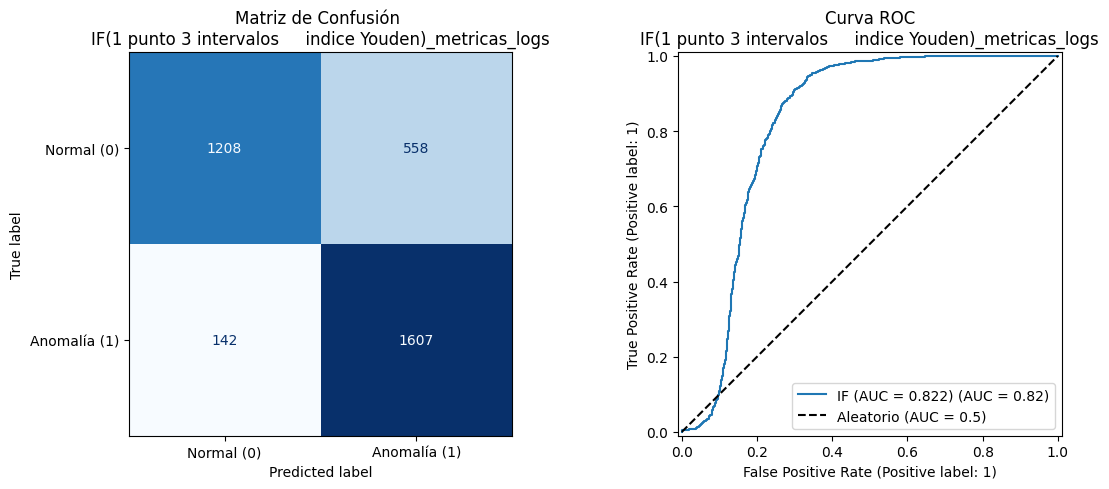

['result/models/IF(1 punto 3 intervalos     indice Youden)_metricas_logs.joblib']

In [108]:

model_name = f'IF(1 punto 3 intervalos     indice Youden)_metricas_logs'
N += 1

# 2. Entrenar el Isolation Forest
model = IsolationForest(
    n_estimators=200, 
    max_samples='auto', 
    contamination='auto',        
    random_state=SEED
)
model.fit(X_correct_train)


#usamos el conjunto de validacion para obtener curva ROC y establecer el umbral de decision usnado indice de Youden
#y_true = df_result.iloc[idx_val]['label'].apply(lambda x: 0 if x == 'correct' else 1)
y_true = df_result.loc[idx_val, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
scores = model.decision_function(X_val)
y_scores_roc = -scores  
roc_auc = roc_auc_score(y_true, y_scores_roc)
fpr, tpr, thresholds = roc_curve(y_true, y_scores_roc)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

#calcumamos la prediccion para el conjunto de test
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
scores = model.decision_function(X_test)
y_scores_roc = -scores  
roc_auc = roc_auc_score(y_true, y_scores_roc)
fpr, tpr, thresholds = roc_curve(y_true, y_scores_roc)
y_pred = (y_scores_roc >= optimal_threshold).astype(int)



# Guardar en el DataFrame global
df_result[f'result_({model_name})'] = float('nan')
df_result[f'scores_({model_name})'] = float('nan')
df_result.loc[idx_test, f'result_({model_name})'] = y_pred
df_result.loc[idx_test, f'scores_({model_name})'] = scores

# 6. Métricas y matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f'--- {model_name} (Umbral Youden: {optimal_threshold:.4f}) ---')
print(f'Accuracy    = {acc}')
print(f'Precision   = {precision}')
print(f'Recall      = {recall}')
print(f'Specificity = {specificity}')    
print(f'F1          = {f1}')

parametros = {'contaminacion': contaminacion, 'metodo': 'youden', 'umbral_youden': float(optimal_threshold)}

reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc)
}
lista_result.append(reg_resultado_algoritmo)

# 7. Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusión \n{model_name}')

RocCurveDisplay.from_predictions(y_true, y_scores_roc, ax=axes[1], name=f'IF (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
axes[1].set_title(f'Curva ROC\n{model_name}')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

paquete = {
    'model_name' : model_name,
    'model'      : model,
    'parametros' : {'contaminacion':contaminacion,'threshold':optimal_threshold},
    'resultado'  : {'accuracy':acc,'precision':precision,'recall':recall,'f1':f1,'specificity':specificity}
}
joblib.dump(paquete, f'{FOLDER_SALIDA}/models/{model_name}.joblib')



    

## <span style="color:#2ca02c">2.7. Analisis de importancia de features para conseguir un modelo de detecion de a nomalias con menos caracteristicas</span>

<span style="color:#2ca02c">Usamos el modelo de 1 punto y 3 intervalos con umbral calculado con indice de Youden</span>

In [87]:


from sklearn.metrics import f1_score, make_scorer

# Definimos una métrica personalizada para F1 que maneje el binarizado de Isolation Forest (1 y -1)
def custom_f1_score(y_true, y_pred_raw):
    # Convertimos las salidas -1/1 del predict del IsolationForest a 0/1
    y_pred_bin = [0 if x == 1 else 1 for x in y_pred_raw]
    return f1_score(y_true, y_pred_bin, zero_division=0)

f1_scorer = make_scorer(custom_f1_score)

# Ejecutamos la importancia usando el scorer personalizado
result = permutation_importance(
    model, X_test, y_true, 
    scoring=f1_scorer,
    n_repeats=10, 
    random_state=SEED, 
    n_jobs=1
)

# Creamos el DataFrame de importancia
df_importancia = pd.DataFrame({
    'Caracteristica': lista_metric_name_vector,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=False)



In [88]:
print(df_importancia.head(40))

                       Caracteristica  Importancia
54   light-oauth2-oauth2-client-1(63)     0.002168
147     light-oauth2-oauth2-key-1(24)     0.002168
53   light-oauth2-oauth2-client-1(62)     0.002053
56   light-oauth2-oauth2-client-1(65)     0.001140
105    light-oauth2-oauth2-code-1(47)     0.001140
120    light-oauth2-oauth2-code-1(61)     0.001140
181  light-oauth2-oauth2-service-1(0)     0.001140
107    light-oauth2-oauth2-code-1(49)     0.001140
212  light-oauth2-oauth2-token-1(125)     0.001140
144     light-oauth2-oauth2-key-1(20)     0.001140
39   light-oauth2-oauth2-client-1(49)     0.001140
116    light-oauth2-oauth2-code-1(57)     0.001140
94     light-oauth2-oauth2-code-1(34)     0.001140
155     light-oauth2-oauth2-key-1(35)     0.001140
272   light-oauth2-oauth2-token-1(47)     0.001140
104    light-oauth2-oauth2-code-1(46)     0.001140
149     light-oauth2-oauth2-key-1(27)     0.001026
23   light-oauth2-oauth2-client-1(33)     0.001026
99     light-oauth2-oauth2-code

In [110]:
X_matrix_acumulado=X_matrix_reducida.copy()

In [ ]:
lista_result = []

contaminacion = 0.002  # Esto no sirve para nada ya que calcularemos el umbral de decisión aparte
resultados_loop_features = []

for n_feat in range(50, 312):
    # 1. Selección de datos reducidos por importancia
    lista_idx_reducida_IF = df_importancia.head(n_feat).index.tolist()
    
    X_matrix_reducida = X_matrix_acumulado[:, lista_idx_reducida_IF]
    X_correct_train   = X_matrix_reducida[idx_correct_train]
    X_val             = X_matrix_reducida[idx_val]
    X_test            = X_matrix_reducida[idx_test]

    # 2. Entrenamiento del modelo
    model = IsolationForest(
        n_estimators=200, 
        max_samples='auto', 
        contamination=contaminacion,        
        random_state=SEED
    )
    model.fit(X_correct_train)

    model_name = f'IF(umbral con indice de Youden)_{n_feat}_features(metricas_logs)'
    joblib.dump(model, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    
    # 3. Cálculo del umbral óptimo usando el conjunto de VALIDACIÓN (idx_val)
    y_true_val = df_result.loc[idx_val, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    scores_val = model.decision_function(X_val)
    y_scores_val_roc = -scores_val  
    
    fpr_val, tpr_val, thresholds_val = roc_curve(y_true_val, y_scores_val_roc)
    optimal_idx = np.argmax(tpr_val - fpr_val)
    optimal_threshold = thresholds_val[optimal_idx]

    # 4. Predicción y evaluación sobre el conjunto de TEST (idx_test) usando el umbral de validación
    y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    scores = model.decision_function(X_test)
    y_scores_roc = -scores  
    
    y_pred = (y_scores_roc >= optimal_threshold).astype(int)
    roc_auc = roc_auc_score(y_true, y_scores_roc)


    
    # 5. Componentes de la matriz de confusión y métricas
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(
        f'[{model_name}] -> Acc: {acc:.4f} | Prec: {precision:.4f} | '
        f'Rec: {recall:.4f} | Spec: {specificity:.4f} | F1: {f1:.4f} | AUC: {roc_auc:.4f}'
    )
    
    parametros = {'n_feat': n_feat, 'contaminacion': contaminacion, 'umbral_youden': float(optimal_threshold)}
    
    # 6. Registro de resultados
    reg_resultado_algoritmo = {
        'test_name': model_name,
        'parametros': json.dumps(parametros),
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1),
        'roc_auc': float(roc_auc)
    }
    lista_result.append(reg_resultado_algoritmo)
    
    paquete = {
        'model_name'     : model_name,
        'model'          : model,
        'parametros'     : {'contaminacion': contaminacion, 'threshold': optimal_threshold},
        'lista_features' : df_importancia['Caracteristica'][:n_feat],
        'resultado'      : {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'specificity': specificity}
    }
    joblib.dump(paquete, f'{FOLDER_SALIDA}/models/{model_name}.joblib')



In [115]:
with pd.option_context('display.max_rows', None):
    display(df_result_algoritmos)

,test_name,parametros,TP,FP,TN,FN,accuracy,precision,recall,specificity,f1_score,roc_auc
0,IF(umbral con indice de Youden)_50_features(me...,"{""n_feat"": 50, ""contaminacion"": 0.002, ""umbral...",1446,966,800,303,0.638976,0.599502,0.826758,0.453001,0.695025,0.649057
1,IF(umbral con indice de Youden)_51_features(me...,"{""n_feat"": 51, ""contaminacion"": 0.002, ""umbral...",1365,951,815,384,0.620199,0.589378,0.780446,0.461495,0.671587,0.635773
2,IF(umbral con indice de Youden)_52_features(me...,"{""n_feat"": 52, ""contaminacion"": 0.002, ""umbral...",1502,1107,659,247,0.614794,0.575700,0.858776,0.373160,0.689307,0.612853
3,IF(umbral con indice de Youden)_53_features(me...,"{""n_feat"": 53, ""contaminacion"": 0.002, ""umbral...",1467,1103,663,282,0.605974,0.570817,0.838765,0.375425,0.679324,0.591578
4,IF(umbral con indice de Youden)_54_features(me...,"{""n_feat"": 54, ""contaminacion"": 0.002, ""umbral...",1416,868,898,333,0.658321,0.619965,0.809605,0.508494,0.702207,0.673067
5,IF(umbral con indice de Youden)_55_features(me...,"{""n_feat"": 55, ""contaminacion"": 0.002, ""umbral...",1473,915,851,276,0.661166,0.616834,0.842196,0.481880,0.712110,0.685167
6,IF(umbral con indice de Youden)_56_features(me...,"{""n_feat"": 56, ""contaminacion"": 0.002, ""umbral...",1529,845,921,220,0.697013,0.644061,0.874214,0.521518,0.741693,0.733855
7,IF(umbral con indice de Youden)_57_features(me...,"{""n_feat"": 57, ""contaminacion"": 0.002, ""umbral...",1577,564,1202,172,0.790612,0.736572,0.901658,0.680634,0.810797,0.838062
8,IF(umbral con indice de Youden)_58_features(me...,"{""n_feat"": 58, ""contaminacion"": 0.002, ""umbral...",1532,672,1094,217,0.747084,0.695100,0.875929,0.619479,0.775108,0.790640
9,IF(umbral con indice de Youden)_59_features(me...,"{""n_feat"": 59, ""contaminacion"": 0.002, ""umbral...",1561,589,1177,188,0.778947,0.726047,0.892510,0.666478,0.800718,0.818718


[IF(umbral con indice de Youden)_102_features(metricas_logs)] -> Acc: 0.8945 | Prec: 0.8448 | Rec: 0.9651 | Spec: 0.8245 | F1: 0.9010 | AUC: 0.9139


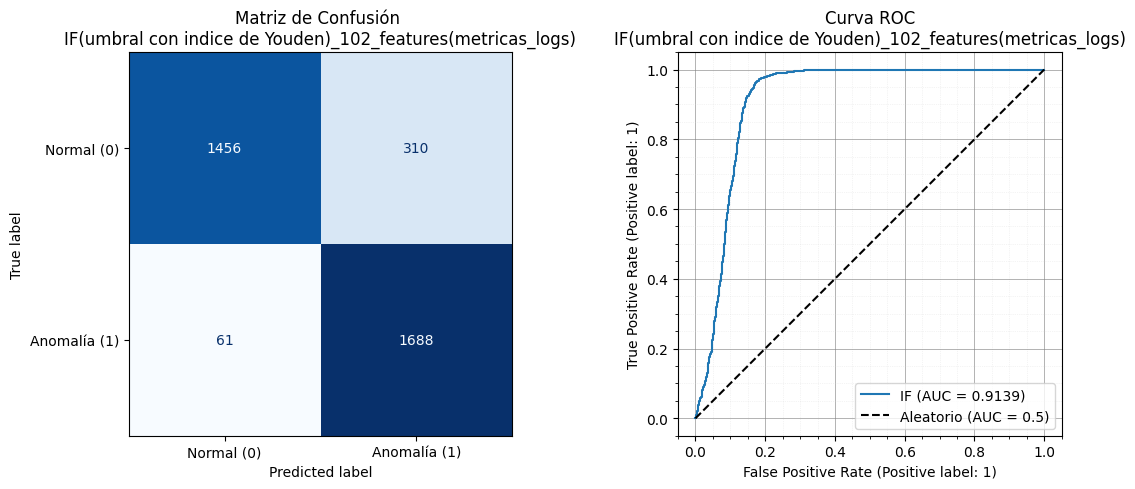

In [146]:

# Definimos el número de características óptimo
n_feat = 102
model_name = f'IF(umbral con indice de Youden)_{n_feat}_features(metricas_logs)'

# 1. Selección de datos reducidos por importancia (102 features)
lista_idx_reducida_IF = df_importancia.head(n_feat).index.tolist()
lista_nombres_features = df_importancia.loc[lista_idx_reducida_IF, 'Caracteristica'].tolist()

X_matrix_reducida = X_matrix_acumulado[:, lista_idx_reducida_IF]
X_correct_train   = X_matrix_reducida[idx_correct_train]
X_val             = X_matrix_reducida[idx_val]
X_test            = X_matrix_reducida[idx_test]

# 2. Entrenamiento del modelo
model = IsolationForest(
    n_estimators=200, 
    max_samples='auto', 
    contamination=contaminacion,        
    random_state=SEED
)
model.fit(X_correct_train)

# 3. Cálculo del umbral óptimo usando el conjunto de VALIDACIÓN (idx_val)
y_true_val = df_result.loc[idx_val, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
scores_val = model.decision_function(X_val)
y_scores_val_roc = -scores_val  

fpr_val, tpr_val, thresholds_val = roc_curve(y_true_val, y_scores_val_roc)
optimal_idx = np.argmax(tpr_val - fpr_val)
optimal_threshold = thresholds_val[optimal_idx]

# 4. Predicción y evaluación sobre el conjunto de TEST (idx_test) usando el umbral de validación
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
scores = model.decision_function(X_test)
y_scores_roc = -scores  

y_pred = (y_scores_roc >= optimal_threshold).astype(int)
roc_auc = roc_auc_score(y_true, y_scores_roc)
fpr, tpr, thresholds = roc_curve(y_true, y_scores_roc)

# Guardamos los scores y predicciones en el DataFrame global sin fragmentarlo
nuevas_columnas = {}
s_res = pd.Series(float('nan'), index=df_result.index)
s_res.loc[idx_test] = y_pred
nuevas_columnas[f'result_({model_name})'] = s_res

s_sco = pd.Series(float('nan'), index=df_result.index)
s_sco.loc[idx_test] = scores
nuevas_columnas[f'scores_({model_name})'] = s_sco

df_result = pd.concat([df_result, pd.DataFrame(nuevas_columnas)], axis=1)

# 5. Componentes de la matriz de confusión y métricas
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

print(
    f'[{model_name}] -> Acc: {acc:.4f} | Prec: {precision:.4f} | '
    f'Rec: {recall:.4f} | Spec: {specificity:.4f} | F1: {f1:.4f} | AUC: {roc_auc:.4f}'
)

parametros = {
    'n_feat': n_feat, 
    'contaminacion': contaminacion, 
    'umbral_youden': float(optimal_threshold),
    'features_usadas': lista_nombres_features
}

# 6. Registro de resultados
reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp),
    'FP': int(fp),
    'TN': int(tn),
    'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc)
}
lista_result.append(reg_resultado_algoritmo)

paquete = {
    'model_name'     : model_name,
    'model'          : model,
    'parametros'     : {'contaminacion': contaminacion, 'threshold': optimal_threshold, 'features_usadas': lista_nombres_features},
    'lista_features' : lista_nombres_features,
    'resultado'      : {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'specificity': specificity}
}
joblib.dump(paquete, f'{FOLDER_SALIDA}/models/{model_name}.joblib')

# 7. Visualización (Matriz de confusión y Curva ROC cuadrada con rejillas secundarias)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Confusión
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusión \n{model_name}')
axes[0].set_aspect('equal')

# Curva ROC
axes[1].plot(fpr, tpr, label=f'IF (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate (Positive label: 1)')
axes[1].set_ylabel('True Positive Rate (Positive label: 1)')
axes[1].set_title(f'Curva ROC\n{model_name}')
axes[1].legend(loc='lower right')
axes[1].set_aspect('equal')

# Rejillas secundarias y principales en la curva ROC
axes[1].minorticks_on()
axes[1].grid(which='major', linestyle='-', linewidth='0.7', color='gray', alpha=0.6)
axes[1].grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray', alpha=0.5)

plt.tight_layout()
plt.show()

In [125]:

# 1. Partimos de la lista inicial de características de tu mejor modelo (ej. 102)
features_actuales = df_importancia.head(110)['Caracteristica'].tolist()

def evaluar_features(lista_feat):
    # Obtenemos los índices originales de df_importancia para estas características
    indices = [df_importancia[df_importancia['Caracteristica'] == f].index[0] for f in lista_feat]
    X_m = X_matrix_acumulado[:, indices]
    X_train = X_m[idx_correct_train]
    X_val = X_m[idx_val]
    X_test = X_m[idx_test]
    
    model = IsolationForest(n_estimators=200, max_samples='auto', contamination=contaminacion, random_state=SEED)
    model.fit(X_train)
    
    y_true_val = df_result.loc[idx_val, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    scores_val = model.decision_function(X_val)
    fpr_val, tpr_val, thresholds_val = roc_curve(y_true_val, -scores_val)
    opt_thresh = thresholds_val[np.argmax(tpr_val - fpr_val)]
    
    y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    scores = model.decision_function(X_test)
    y_pred = (-scores >= opt_thresh).astype(int)
    
    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    
    return f1, acc, indices

# Evaluamos el baseline inicial y guardamos la mejor combinación inicial
mejor_f1, mejor_acc, mejores_indices_historicos = evaluar_features(features_actuales)
mejores_features_historicas = features_actuales.copy()

print(f"--> Baseline con {len(features_actuales)} features | F1 inicial: {mejor_f1:.4f} | Acc inicial: {mejor_acc:.4f}\n")

intentos_sin_mejora = 0
iteracion = 0

while len(features_actuales) > 1:
    iteracion += 1
    print(f"\n--- Iteración {iteracion} (Features actuales: {len(features_actuales)}) ---",end='\r')
    
    mejor_f1_ronda = -1
    mejor_acc_ronda = -1
    mejor_candidato_features = None
    
    # Probamos a quitar CADA una de las características actuales de una en una
    for i, feat_a_quitar in enumerate(features_actuales):
        features_prueba = features_actuales.copy()
        features_prueba.pop(i)
        
        f1_test, acc_test, _ = evaluar_features(features_prueba)
        
        # Buscamos la MEJOR opción de esta ronda concreta
        if f1_test > mejor_f1_ronda:
            mejor_f1_ronda = f1_test
            mejor_acc_ronda = acc_test
            mejor_candidato_features = features_prueba

    print(f"  -> Mejor opción de esta ronda (quitando una): F1: {mejor_f1_ronda:.4f} | Acc: {mejor_acc_ronda:.4f}")

    # Actualizamos obligatoriamente las features actuales con el mejor resultado de esta ronda para seguir avanzando
    features_actuales = mejor_candidato_features

    # Comprobamos si esta ronda ha batido el récord histórico global de F1
    if mejor_f1_ronda > mejor_f1:
        mejor_f1 = mejor_f1_ronda
        mejor_acc = mejor_acc_ronda
        mejores_features_historicas = features_actuales.copy()
        intentos_sin_mejora = 0  # Reiniciamos el contador porque hubo récord histórico
        print(f"✨ ¡Nuevo récord histórico! F1: {mejor_f1:.4f} | Acc: {mejor_acc:.4f} (Features restantes: {len(features_actuales)})")
    else:
        intentos_sin_mejora += 1
        print(f"⚠️ No se supera el récord histórico ({mejor_f1:.4f}). Intentos consecutivos sin batir récord: {intentos_sin_mejora}/10")
        
        # Si acumulamos 10 iteraciones seguidas sin batir el récord histórico, paramos
        if intentos_sin_mejora >= 10:
            print(f"\n🛑 Parada anticipada: Se han acumulado 10 iteraciones sin superar el mejor F1 histórico.")
            break

# Obtenemos los índices definitivos de la mejor combinación histórica encontrada
mejores_indices_finales = [df_importancia[df_importancia['Caracteristica'] == f].index[0] for f in mejores_features_historicas]

print(f"\n==========================================")
print(f"PROCESO FINALIZADO.")
print(f"Mejor F1 histórico alcanzado: {mejor_f1:.4f} (Accuracy: {mejor_acc:.4f})")
print(f"Número de características óptimas: {len(mejores_indices_finales)}")
print(f"==========================================")

display(mejores_indices_finales)

--> Baseline con 110 features | F1 inicial: 0.8489 | Acc inicial: 0.8367


  -> Mejor opción de esta ronda (quitando una): F1: 0.8921 | Acc: 0.8836
✨ ¡Nuevo récord histórico! F1: 0.8921 | Acc: 0.8836 (Features restantes: 109)

  -> Mejor opción de esta ronda (quitando una): F1: 0.8924 | Acc: 0.8848
✨ ¡Nuevo récord histórico! F1: 0.8924 | Acc: 0.8848 (Features restantes: 108)

  -> Mejor opción de esta ronda (quitando una): F1: 0.8951 | Acc: 0.8876
✨ ¡Nuevo récord histórico! F1: 0.8951 | Acc: 0.8876 (Features restantes: 107)

  -> Mejor opción de esta ronda (quitando una): F1: 0.8991 | Acc: 0.8925
✨ ¡Nuevo récord histórico! F1: 0.8991 | Acc: 0.8925 (Features restantes: 106)

  -> Mejor opción de esta ronda (quitando una): F1: 0.8768 | Acc: 0.8688
⚠️ No se supera el récord histórico (0.8991). Intentos consecutivos sin batir récord: 1/10

  -> Mejor opción de esta ronda (quitando una): F1: 0.9030 | Acc: 0.8962
✨ ¡Nuevo récord histórico! F1: 0.9030 | Acc: 0.8962 (Features restantes: 104)



[np.int64(131),
 np.int64(286),
 np.int64(191),
 np.int64(17),
 np.int64(79),
 np.int64(127),
 np.int64(50)]

--- IF(1 punto 3 intervalos seleccion features Youden) (Umbral Youden: 0.1005) ---
Accuracy    = 0.9943
Precision   = 0.9915
Recall      = 0.9971
Specificity = 0.9915
F1          = 0.9943
AUC         = 0.9998


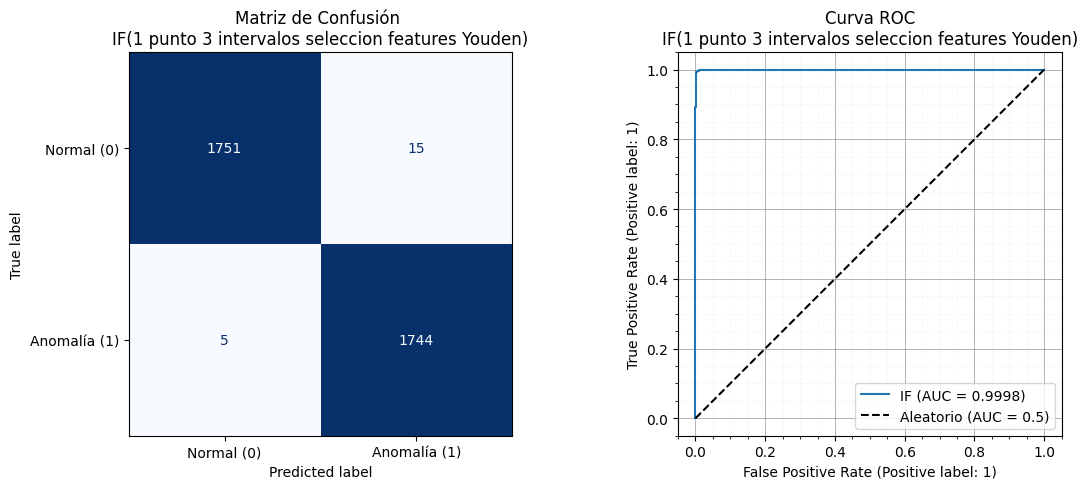

['result/models/IF(1 punto 3 intervalos seleccion features Youden).joblib']

In [133]:
model_name = 'IF(1 punto 3 intervalos seleccion features Youden)'

# 1. Selección de datos con las 7 mejores características óptimas obtenidas
X_matrix_reducida = X_matrix_acumulado[:, mejores_indices_finales]
X_correct_train   = X_matrix_reducida[idx_correct_train]
X_val             = X_matrix_reducida[idx_val]
X_test            = X_matrix_reducida[idx_test]

# 2. Entrenar el Isolation Forest
model = IsolationForest(
    n_estimators=200, 
    max_samples='auto', 
    contamination='auto',        
    random_state=SEED
)
model.fit(X_correct_train)

# 3. Usamos el conjunto de validación para obtener el umbral de decisión usando el índice de Youden
y_true_val = df_result.loc[idx_val, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
scores_val = model.decision_function(X_val)
y_scores_val_roc = -scores_val  

fpr_val, tpr_val, thresholds_val = roc_curve(y_true_val, y_scores_val_roc)
optimal_idx = np.argmax(tpr_val - fpr_val)
optimal_threshold = thresholds_val[optimal_idx]

# 4. Calculamos la predicción para el conjunto de test
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
scores = model.decision_function(X_test)
y_scores_roc = -scores  

roc_auc = roc_auc_score(y_true, y_scores_roc)
fpr, tpr, thresholds = roc_curve(y_true, y_scores_roc)
y_pred = (y_scores_roc >= optimal_threshold).astype(int)

# 5. Guardar en el DataFrame global (evitando fragmentación con dict temporal)
nuevas_columnas = {}
s_res = pd.Series(float('nan'), index=df_result.index)
s_res.loc[idx_test] = y_pred
nuevas_columnas[f'result_({model_name})'] = s_res

s_sco = pd.Series(float('nan'), index=df_result.index)
s_sco.loc[idx_test] = scores
nuevas_columnas[f'scores_({model_name})'] = s_sco

df_result = pd.concat([df_result, pd.DataFrame(nuevas_columnas)], axis=1)

# 6. Métricas y matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f'--- {model_name} (Umbral Youden: {optimal_threshold:.4f}) ---')
print(f'Accuracy    = {acc:.4f}')
print(f'Precision   = {precision:.4f}')
print(f'Recall      = {recall:.4f}')
print(f'Specificity = {specificity:.4f}')    
print(f'F1          = {f1:.4f}')
print(f'AUC         = {roc_auc:.4f}')

# Obtenemos la lista de nombres de las características usadas
lista_nombres_features = df_importancia.loc[mejores_indices_finales, 'Caracteristica'].tolist()

parametros = {
    'n_feat': len(mejores_indices_finales), 
    'contaminacion': contaminacion, 
    'metodo': 'youden', 
    'umbral_youden': float(optimal_threshold),
    'features_usadas': lista_nombres_features
}

reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc)
}
lista_result.append(reg_resultado_algoritmo)

# 7. Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matriz de confusión
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusión \n{model_name}')
axes[0].set_aspect('equal')

# 2. Curva ROC
axes[1].plot(fpr, tpr, label=f'IF (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate (Positive label: 1)')
axes[1].set_ylabel('True Positive Rate (Positive label: 1)')
axes[1].set_title(f'Curva ROC\n{model_name}')
axes[1].legend(loc='lower right')
axes[1].set_aspect('equal')

# Activamos las líneas divisorias secundarias en la Curva ROC
axes[1].minorticks_on()
axes[1].grid(which='major', linestyle='-', linewidth='0.7', color='gray', alpha=0.6)
axes[1].grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray', alpha=0.5)

plt.tight_layout()
plt.show()

paquete = {
    'model_name'     : model_name,
    'model'          : model,
    'parametros'     : {'contaminacion': contaminacion, 'threshold': optimal_threshold, 'features_usadas': lista_nombres_features},
    'lista_features' : lista_nombres_features,
    'resultado'      : {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'specificity': specificity}
}
joblib.dump(paquete, f'{FOLDER_SALIDA}/models/{model_name}.joblib')

In [131]:
lista_nombres_features

['light-oauth2-oauth2-code-1(8)',
 'light-oauth2-oauth2-token-1(6)',
 'light-oauth2-oauth2-token-1(1)',
 'light-oauth2-oauth2-client-1(27)',
 'light-oauth2-oauth2-code-1(18)',
 'light-oauth2-oauth2-code-1(68)',
 'light-oauth2-oauth2-client-1(6)']